# Ablation Sampling Exploration

This notebook trains a single model and keeps two perturbation estimands separate:

- **Coverage analysis:** enriches rare `(center marker, perturbed marker, hop)` combinations for heatmaps and full effect distributions.
- **Population analysis:** samples representative center cells to estimate conditional and population-average ablation effects under either equal-cell or equal-organoid weighting.

All perturbations use `mode="single"`. For every marker and hop, a separate conditional-effect sample is topped up to a shared minimum where possible. Top-up centers never enter prevalence estimates or another marker's analysis.


**Setup And Settings**


In [1]:
import copy
import json
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Run this notebook from the repository root or experiments directory.")
DATA_ROOT = PROJECT_ROOT / "training_data"
sys.path.append(str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [ ]:
# Data and filtering: matched to ablation_analysis.ipynb, with extra sampler diagnostics.
EXPERIMENT_GROUP = "ablation_sampling"
DATASET_NAME = "after_cleanup"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_ANALYSIS = 0

USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True
SUBTRACT_CONSTANT_GLOBAL_BASELINE = False

TIMEPOINT_FILTER_MODE = "rest"  # "rest", "day3p5", or "all"
DAY3P5_TIMEPOINT = "day3p5"
FILL_MISSING_COMPLEXITY = False
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
APPLY_QUALITY_FILTERS = True
APPLY_COMPLEXITY_FILTER = False
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = None  # e.g. 2.0 for older datasets with complexity metadata
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Single train/validation split
VAL_FRAC = 0.2
SPLIT_SEED = 42

# Model and training
NUM_LAYERS = 2
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 500
PATIENCE = 30
NUM_WORKERS = 4
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Sampling and single-marker ablation
PERTURBATION_MODE = "single"
SUBGRAPH_SEED = 0
PERTURB_BATCH_SIZE = 128
HEATMAP_SAMPLE_SIZE = 2000
HEATMAP_MIN_CENTER_COUNT = 50
HEATMAP_MIN_PAIR_COUNT = 25

HEATMAP_SAMPLER = "coverage"  # Active sampler for downstream distribution/reuse diagnostics.
HEATMAP_COMPARISON_SAMPLERS = ("coverage", "non_overlapping")
HEATMAP_REUSE_PENALTY = 1.0
HEATMAP_FILL_REUSE_PENALTY = 1.0
HEATMAP_DISPLAY_MIN_CASES = 0

POPULATION_SAMPLE_SIZE = 2000
MIN_MARKER_COUNT_PER_HOP = 75  # Minimum conditional-effect cases for every marker at every hop.
DISTRIBUTION_CENTER_MARKERS = None  # None plots every center marker.

# Optional robust filtering of per-case prediction changes.
OUTLIER_FILTER_METHOD = "mad"  # None or "mad".
OUTLIER_MAD_Z = 3.5
OUTLIER_MIN_GROUP_SIZE = 20
OUTLIER_TAIL = "both"  # "both", "lower", or "upper".

# Output
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = (
    f"{TIMEPOINT_FILTER_MODE}_depth{NUM_LAYERS}_{DATASET_NAME}_"
    f"sampling_comparison_{RUN_TIMESTAMP}"
)
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


def set_all_seeds(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


set_all_seeds(SPLIT_SEED)


In [3]:
def save_figure(fig, name, *, dpi=300):
    for suffix in ("pdf", "png", "svg"):
        fig.savefig(FIGURES_DIR / f"{name}.{suffix}", dpi=dpi, bbox_inches="tight")


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, (torch.dtype, np.dtype)):
        return str(obj)
    return obj


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr
    return arr[:, int(target_index)]


def marker_index(marker):
    marker_list = list(marker_names)
    if marker in marker_list:
        return marker_list.index(marker)
    lower = {str(name).lower(): i for i, name in enumerate(marker_list)}
    key = str(marker).lower()
    if key not in lower:
        raise ValueError(f"Marker {marker!r} not found in marker_names.")
    return lower[key]


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(valid):
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def weighted_quantile(values, quantile, weights=None):
    values = np.asarray(values, dtype=float)
    if weights is None:
        weights = np.ones(len(values), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if len(values) == 0:
        return np.nan
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative /= weights.sum()
    return float(np.interp(quantile, cumulative, values))


def robust_outlier_mask(values, weights=None):
    values = np.asarray(values, dtype=float)
    mask = np.zeros(len(values), dtype=bool)
    if OUTLIER_FILTER_METHOD is None:
        return mask
    if OUTLIER_FILTER_METHOD != "mad":
        raise ValueError('OUTLIER_FILTER_METHOD must be None or "mad".')
    if OUTLIER_TAIL not in {"both", "lower", "upper"}:
        raise ValueError('OUTLIER_TAIL must be "both", "lower", or "upper".')

    valid = np.isfinite(values)
    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        valid &= np.isfinite(weights) & (weights > 0)
    if valid.sum() < OUTLIER_MIN_GROUP_SIZE:
        return mask

    valid_values = values[valid]
    valid_weights = None if weights is None else weights[valid]
    median = weighted_quantile(valid_values, 0.5, valid_weights)
    abs_deviation = np.abs(valid_values - median)
    mad = weighted_quantile(abs_deviation, 0.5, valid_weights)
    robust_scale = 1.4826 * mad
    if not np.isfinite(robust_scale) or robust_scale <= 0:
        return mask

    lower = median - OUTLIER_MAD_Z * robust_scale
    upper = median + OUTLIER_MAD_Z * robust_scale
    valid_mask = np.zeros(len(valid_values), dtype=bool)
    if OUTLIER_TAIL in {"both", "lower"}:
        valid_mask |= valid_values < lower
    if OUTLIER_TAIL in {"both", "upper"}:
        valid_mask |= valid_values > upper
    mask[np.flatnonzero(valid)] = valid_mask
    return mask


def flag_groupwise_outliers(df, group_columns, value_column, weight_column=None):
    # explode() can create duplicate index labels, so assign flags by row position.
    flagged = df.copy().reset_index(drop=True)
    outlier_flags = np.zeros(len(flagged), dtype=bool)
    grouped_positions = flagged.groupby(
        group_columns,
        dropna=False,
        sort=False,
    ).indices
    for positions in grouped_positions.values():
        positions = np.asarray(positions, dtype=int)
        group = flagged.iloc[positions]
        weights = None if weight_column is None else group[weight_column].to_numpy(float)
        outlier_flags[positions] = robust_outlier_mask(
            group[value_column].to_numpy(float),
            weights,
        )
    flagged["is_outlier"] = outlier_flags
    return flagged


## 1. Load And Filter Data


In [4]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_metadata,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    add_log_metadata_features,
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    infer_global_dim,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    promote_metadata_to_graph_tensors,
    snapshot_graph_metadata,
    strip_graph_metadata,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
meta = load_aux_metadata_for_dir(str(data_dir))
attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    marker_names = [f"marker_{i}" for i in range(int(graphs[0].x.size(1)))]
print(f"Loaded {len(graphs)} organoids and {len(marker_names)} markers.")


Loaded 1500 graphs; skipped 0.
Loaded 1500 organoids and 7 markers.


In [5]:
if TIMEPOINT_FILTER_MODE == "rest":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        drop_values={DAY3P5_TIMEPOINT},
        missing="keep",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE == "day3p5":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        keep_values={DAY3P5_TIMEPOINT},
        missing="drop",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE not in (None, "all"):
    raise ValueError('TIMEPOINT_FILTER_MODE must be "rest", "day3p5", or "all".')

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)

if APPLY_QUALITY_FILTERS:
    if FILL_MISSING_COMPLEXITY:
        graphs = fill_missing_metadata_for_group(
            graphs,
            field="complexity",
            fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
            dataset=MISSING_COMPLEXITY_GROUP["dataset"],
            timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
        )

    graphs, spherical = filter_graphs_by_sphericity(
        graphs,
        max_sphericity=SPHERICITY_MAX,
        print_summary=True,
        return_rejected=True,
    )
    spherical = filter_graphs_by_marker_diversity(
        spherical,
        min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
        print_summary=True,
    )
    if APPLY_COMPLEXITY_FILTER:
        if COMPLEXITY_MIN is None:
            raise ValueError("COMPLEXITY_MIN must be set when APPLY_COMPLEXITY_FILTER=True.")
        graphs = filter_graphs_by_numeric_metadata(
            graphs,
            key="complexity",
            min_value=COMPLEXITY_MIN,
            allow_missing=False,
            inplace=False,
            print_summary=True,
        )
    else:
        print("Skipping complexity filter; after_cleanup does not use this filter.")
else:
    print("Skipping quality filters.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
print(f"After filtering: {len(graphs)} organoids.")


filter_graphs_by_metadata(key='timepoint'): kept 1210 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    290    0.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
20251201         day4p5              278    278    1.000
filter_graphs_by_blacklist(n_keys=17): kept 1193 / 1210 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                330    342    0.965
20250929         day4p5              112    113    0.991
20250929         day4p5-more         475    477    0.996
20251201         day4p5              276    278    0.993
filter_graphs_by_sphericity(max_sphericity=0.92): kept 811 / 1193 graphs

dataset          timepoint          kept  total 

## 2. Train One Model


In [6]:
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    key_fn=graph_metadata_key,
    inplace=False,
)
g_train = copy.deepcopy(g_train)
g_val = copy.deepcopy(g_val)

field_specs = [{
    "meta_keys": ["log_surface_area", "log_volume", "log_volume_over_area", "log_num_cells"],
    "attr_name": "global_feat",
    "kind": "graph_vector",
    "dtype": torch.float32,
}]
if USE_GLOBAL_FEATURES:
    g_train = promote_metadata_to_graph_tensors(
        add_log_metadata_features(g_train, inplace=False), field_specs, inplace=False,
    )
    g_val = promote_metadata_to_graph_tensors(
        add_log_metadata_features(g_val, inplace=False), field_specs, inplace=False,
    )

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)
g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

if USE_GLOBAL_FEATURES:
    standardize_graph_global_features(g_train, g_val, attr_name="global_feat", robust=False)

if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
    target_transform = ChainedTargetTransform([
        GlobalBaselineResidualTransform(num_workers=NUM_WORKERS),
        AsinhStandardizeTransform(robust=True),
    ])
else:
    target_transform = AsinhStandardizeTransform(robust=True)
target_transform.fit(g_train)
target_transform.transform_graphs(g_train, in_place=True)
target_transform.transform_graphs(g_val, in_place=True)

model = GINCurvature(
    n_markers=int(g_train[0].x.size(1)),
    global_dim=infer_global_dim(g_train),
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
)
train_config = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=[WeightedLossTerm(
        name="edge", fn=edge_loss_term, weight=EDGE_LOSS_WEIGHT, params=EDGE_LOSS_PARAMS,
    )],
)
model, metrics, history = train(model, g_train, g_val, train_config)
print(metrics)


epoch 001 | train loss 0.5203 mae 0.7736 | val loss 0.4509 mae 0.7290
epoch 002 | train loss 0.4496 mae 0.7280 | val loss 0.4136 mae 0.7023
epoch 003 | train loss 0.4274 mae 0.7109 | val loss 0.3948 mae 0.6904
epoch 004 | train loss 0.4108 mae 0.7026 | val loss 0.3743 mae 0.6763
epoch 005 | train loss 0.3976 mae 0.6910 | val loss 0.3665 mae 0.6638
epoch 006 | train loss 0.3892 mae 0.6843 | val loss 0.3508 mae 0.6601
epoch 007 | train loss 0.3820 mae 0.6811 | val loss 0.3448 mae 0.6570
epoch 008 | train loss 0.3743 mae 0.6778 | val loss 0.3429 mae 0.6529
epoch 009 | train loss 0.3755 mae 0.6788 | val loss 0.3546 mae 0.6646
epoch 010 | train loss 0.3709 mae 0.6758 | val loss 0.3349 mae 0.6466
epoch 011 | train loss 0.3666 mae 0.6764 | val loss 0.3446 mae 0.6554
epoch 012 | train loss 0.3674 mae 0.6747 | val loss 0.3288 mae 0.6447
epoch 013 | train loss 0.3610 mae 0.6737 | val loss 0.3254 mae 0.6428
epoch 014 | train loss 0.3557 mae 0.6695 | val loss 0.3202 mae 0.6432
epoch 015 | train lo

In [7]:
from src.inference.predict import predict_targets

y_true, y_pred, _ = predict_targets(
    g_val, model, batch_size=BATCH_SIZE, target_transform=target_transform,
)
y_true = select_target_column(y_true, TARGET_INDEX_FOR_ANALYSIS)
y_pred = select_target_column(y_pred, TARGET_INDEX_FOR_ANALYSIS)
print("Validation MSE:", np.mean((y_pred - y_true) ** 2))
print("Validation MAE:", np.mean(np.abs(y_pred - y_true)))


Validation MSE: 0.002037247878211799
Validation MAE: 0.030409575509327186


## 3. Build Validation Ego-Subgraphs


In [8]:
from src.data.subgraphs import build_ego_subgraphs_for_dataset

val_subgraphs = build_ego_subgraphs_for_dataset(
    g_val,
    num_hops=NUM_LAYERS,
    max_centers_per_graph=None,
    seed=SUBGRAPH_SEED,
    copy_graph_level_attrs=True,
)
print(f"Built {len(val_subgraphs)} validation ego-subgraphs.")


Built 78828 validation ego-subgraphs.


## 4. Center-Resolved Samples: Mean Heatmaps And Full Distributions

The standard coverage sample is intentionally not population representative. It is used only for conditional center-marker / perturbed-marker diagnostics. The samplers listed in `HEATMAP_COMPARISON_SAMPLERS` are evaluated side by side. By default, `coverage` uses all sampled cases, while `non_overlapping` starts from the same coverage-selected subgraphs and retains non-overlapping perturbation/source cells independently within each `(hop, center_marker, source_marker)` bin.


In [9]:
from src.analysis.perturbation import compute_perturbation_influence_maps
from src.data.subgraph_sampling import (
    flag_non_overlapping_source_cases,
    print_sampling_summary,
    sample_subgraphs_coverage,
    sample_subgraphs_coverage_reuse_aware,
)

coverage_sampler_kwargs = {
    "subgraphs": val_subgraphs,
    "marker_names": marker_names,
    "k_hops": NUM_LAYERS,
    "max_subgraphs": HEATMAP_SAMPLE_SIZE,
    "min_center_count": HEATMAP_MIN_CENTER_COUNT,
    "min_pair_count": HEATMAP_MIN_PAIR_COUNT,
    "seed": SUBGRAPH_SEED,
}
VALID_HEATMAP_SAMPLERS = {"coverage", "reuse_aware", "non_overlapping"}
for sampler_name in set(HEATMAP_COMPARISON_SAMPLERS) | {HEATMAP_SAMPLER}:
    if sampler_name not in VALID_HEATMAP_SAMPLERS:
        raise ValueError(
            f"Unknown heatmap sampler {sampler_name!r}; "
            f"expected one of {sorted(VALID_HEATMAP_SAMPLERS)}."
        )


def run_center_sampler(sample_name):
    if sample_name == "coverage":
        return sample_subgraphs_coverage(**coverage_sampler_kwargs)
    if sample_name == "reuse_aware":
        return sample_subgraphs_coverage_reuse_aware(
            **coverage_sampler_kwargs,
            reuse_penalty=HEATMAP_REUSE_PENALTY,
            fill_reuse_penalty=HEATMAP_FILL_REUSE_PENALTY,
        )
    raise ValueError(f"Unknown subgraph sampler {sample_name!r}.")


def evaluate_center_resolved_sample(sample_name, sampled_subgraphs, sample_info):
    print(f"\nCenter-resolved sampler: {sample_name}")
    if sample_name == "reuse_aware":
        print(
            f"Reuse penalties: greedy={HEATMAP_REUSE_PENALTY}, "
            f"fill={HEATMAP_FILL_REUSE_PENALTY}"
        )
        print(
            "Maximum selected source-cell reuse at one marker/hop:",
            sample_info["max_source_cell_reuse"],
        )
    print_sampling_summary(sample_info, marker_names)

    result = compute_perturbation_influence_maps(
        sampled_subgraphs,
        model,
        marker_names,
        k_hops=NUM_LAYERS,
        mode=PERTURBATION_MODE,
        max_subgraphs=None,
        batch_size=PERTURB_BATCH_SIZE,
        target_index=TARGET_INDEX_FOR_ANALYSIS,
        target_transform=target_transform,
        normalize_by="cases",
        return_case_effects=True,
    )
    cases = pd.DataFrame(result["case_effects"])
    pairs = cases.explode("center_marker_names").rename(
        columns={"center_marker_names": "center_marker"}
    )
    pairs = flag_groupwise_outliers(
        pairs,
        group_columns=["hop", "center_marker", "source_marker"],
        value_column="delta_mu",
    )
    pairs["passes_non_overlap"] = True
    pairs["non_overlap_excluded"] = False
    pairs_filtered = pairs.loc[~pairs["is_outlier"]].copy()
    pairs.to_csv(
        TABLES_DIR / f"{sample_name}_case_effects_with_outlier_flags.csv",
        index=False,
    )
    print(
        f"{sample_name} outliers flagged: {int(pairs['is_outlier'].sum())} / "
        f"{len(pairs)} exploded center-marker cases"
    )
    return {
        "subgraphs": sampled_subgraphs,
        "info": sample_info,
        "result": result,
        "cases": cases,
        "pairs": pairs,
        "pairs_counted": pairs,
        "pairs_filtered": pairs_filtered,
    }


def make_case_non_overlapping_run(base_run, sample_name="non_overlapping"):
    pairs = flag_non_overlapping_source_cases(
        base_run["pairs"],
        graphs=g_val,
        group_columns=("hop", "center_marker", "source_marker"),
        seed=SUBGRAPH_SEED,
        shuffle=True,
    )
    counted = pairs.loc[pairs["passes_non_overlap"]].copy()
    filtered = counted.loc[~counted["is_outlier"]].copy()
    info = dict(base_run["info"])
    info["sampler"] = sample_name
    info["case_non_overlap_group_columns"] = ["hop", "center_marker", "source_marker"]
    info["non_overlap_cases_retained"] = int(pairs["passes_non_overlap"].sum())
    info["non_overlap_cases_excluded"] = int(pairs["non_overlap_excluded"].sum())
    pairs.to_csv(
        TABLES_DIR / f"{sample_name}_case_effects_with_non_overlap_flags.csv",
        index=False,
    )
    print(
        f"{sample_name}: retained {info['non_overlap_cases_retained']} / {len(pairs)} "
        "exploded center-marker cases after case-level non-overlap"
    )
    return {
        **base_run,
        "info": info,
        "pairs": pairs,
        "pairs_counted": counted,
        "pairs_filtered": filtered,
    }


center_sampling_runs = {}
required_samplers = list(dict.fromkeys([*HEATMAP_COMPARISON_SAMPLERS, HEATMAP_SAMPLER]))
if "non_overlapping" in required_samplers and "coverage" not in required_samplers:
    required_samplers.insert(0, "coverage")

for sample_name in required_samplers:
    if sample_name == "non_overlapping":
        if "coverage" not in center_sampling_runs:
            sampled_subgraphs, sample_info = run_center_sampler("coverage")
            center_sampling_runs["coverage"] = evaluate_center_resolved_sample(
                "coverage",
                sampled_subgraphs,
                sample_info,
            )
        center_sampling_runs["non_overlapping"] = make_case_non_overlapping_run(
            center_sampling_runs["coverage"]
        )
        continue

    if sample_name in center_sampling_runs:
        continue
    sampled_subgraphs, sample_info = run_center_sampler(sample_name)
    center_sampling_runs[sample_name] = evaluate_center_resolved_sample(
        sample_name,
        sampled_subgraphs,
        sample_info,
    )

active_run = center_sampling_runs[HEATMAP_SAMPLER]
coverage_subgraphs = active_run["subgraphs"]
coverage_info = active_run["info"]
coverage_result = active_run["result"]
coverage_cases = active_run["cases"]
coverage_pairs = active_run["pairs"]
coverage_pairs_filtered = active_run["pairs_filtered"]
coverage_pairs.to_csv(TABLES_DIR / "coverage_case_effects_with_outlier_flags.csv", index=False)

print(f"\nActive center-resolved sampler for downstream diagnostics: {HEATMAP_SAMPLER}")
display(coverage_pairs.head())



Center-resolved sampler: coverage
Selected 2000 / 78828 subgraphs

Center coverage:
Agr2          covered= 161  target=  50  available=3816  OK
AldoB         covered= 776  target=  50  available=31710  OK
Chroma        covered=  63  target=  50  available= 317  OK
KI67          covered= 579  target=  50  available=21829  OK
LGR5          covered= 318  target=  50  available=11011  OK
Lysozyme      covered=  73  target=  50  available=1014  OK
Serotonin     covered=  73  target=  50  available= 300  OK

Unsatisfied center markers: []
Unsatisfied pair features: 0
coverage outliers flagged: 452 / 12561 exploded center-marker cases
non_overlapping: retained 9934 / 12561 exploded center-marker cases after case-level non-overlap

Active center-resolved sampler for downstream diagnostics: coverage


,subgraph_index,graph_idx,organoid_str,orig_center,hop,source_marker,source_marker_name,target_marker,target_marker_name,center_marker_indices,...,orig_source_node_indices,source_node,orig_source_node,delta_mu,delta_logvar,delta_variance,delta_mse,is_outlier,passes_non_overlap,non_overlap_excluded
0,0,112,organoid_day4p5_A06_54,146,1,0,Agr2,None,None,"[0, 1, 2, 3, 6]",...,[147],11,147,-0.005239,-0.059866,-0.000102,-0.00034,False,True,False
1,0,112,organoid_day4p5_A06_54,146,1,0,Agr2,None,None,"[0, 1, 2, 3, 6]",...,[147],11,147,-0.005239,-0.059866,-0.000102,-0.00034,False,True,False
2,0,112,organoid_day4p5_A06_54,146,1,0,Agr2,None,None,"[0, 1, 2, 3, 6]",...,[147],11,147,-0.005239,-0.059866,-0.000102,-0.00034,False,True,False
3,0,112,organoid_day4p5_A06_54,146,1,0,Agr2,None,None,"[0, 1, 2, 3, 6]",...,[147],11,147,-0.005239,-0.059866,-0.000102,-0.00034,False,True,False
4,0,112,organoid_day4p5_A06_54,146,1,0,Agr2,None,None,"[0, 1, 2, 3, 6]",...,[147],11,147,-0.005239,-0.059866,-0.000102,-0.00034,False,True,False


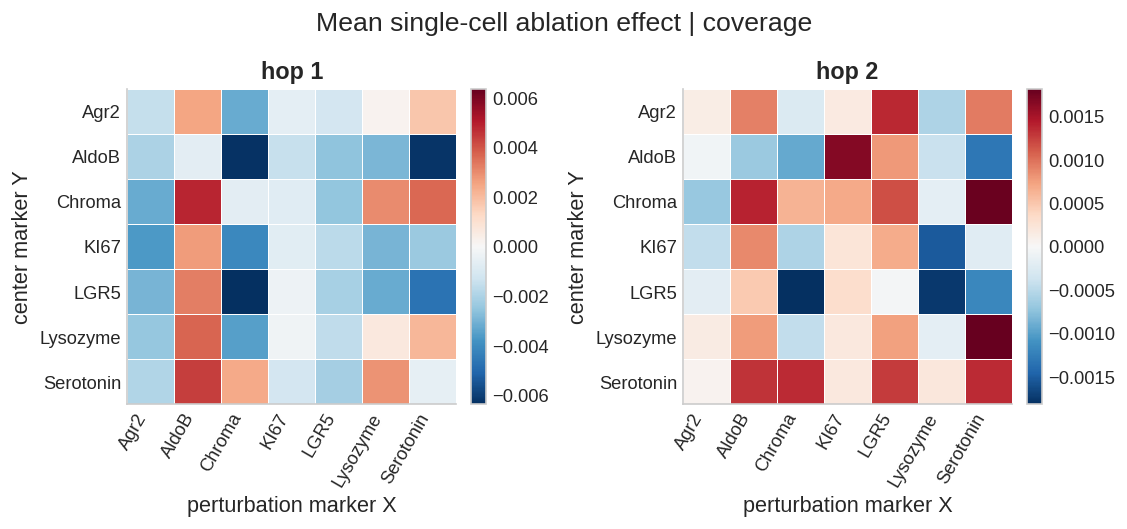

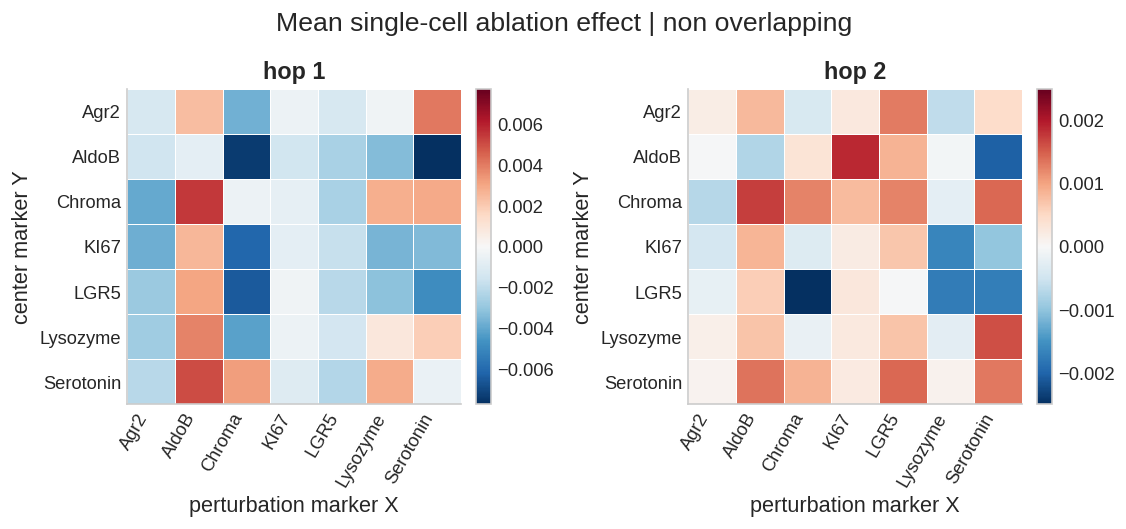

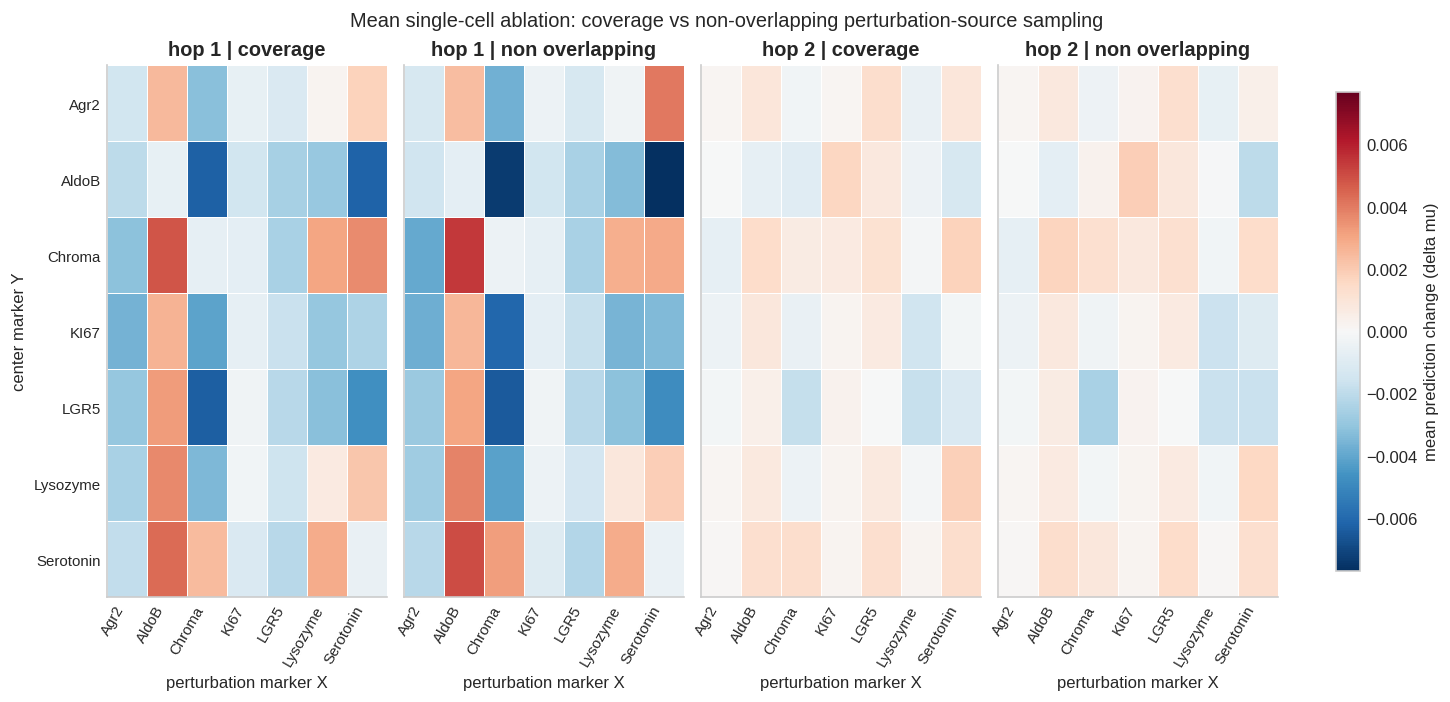

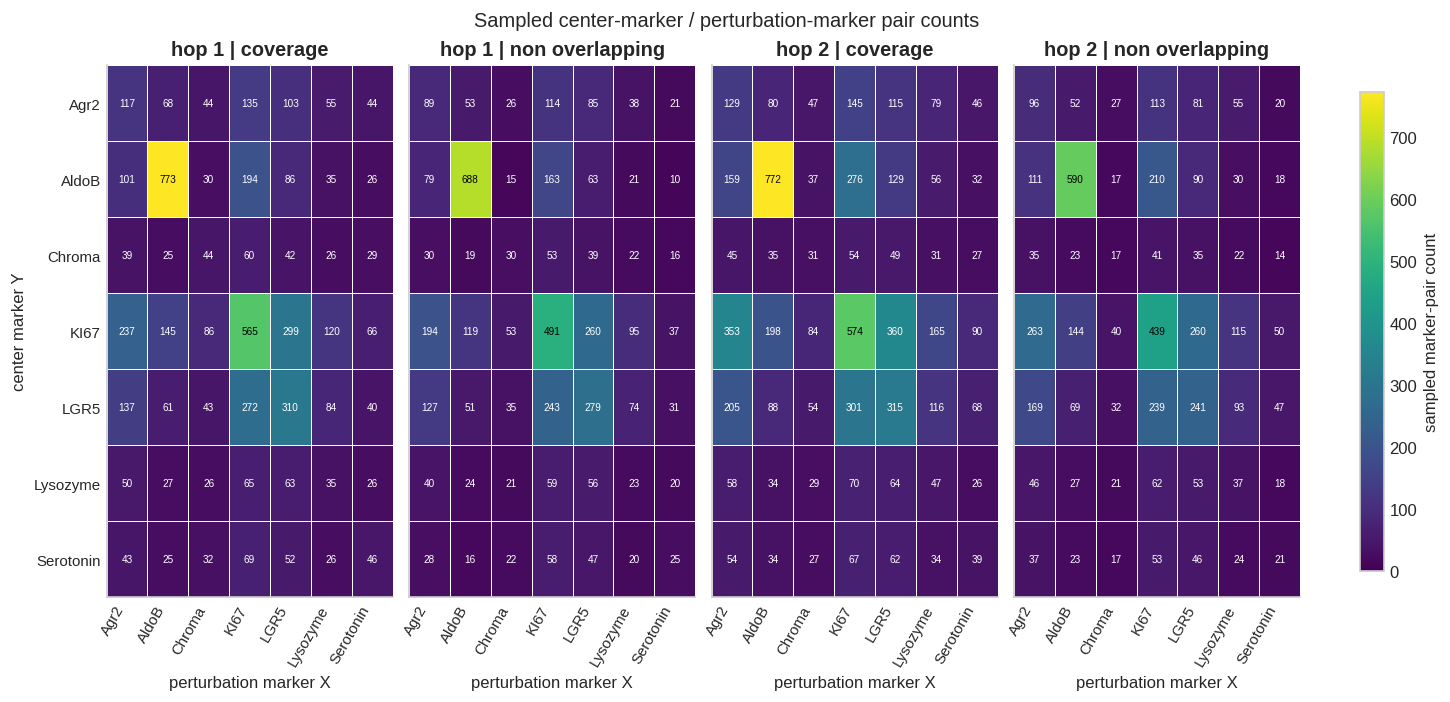

In [10]:
from matplotlib.patches import Rectangle
from src.plotting.influence_maps import plot_influence_center_resolved


def center_resolved_arrays(pair_df, marker_names, hops):
    n_hops = len(hops)
    n_markers = len(marker_names)
    means = np.full((n_hops, n_markers, n_markers), np.nan, dtype=float)
    counts = np.zeros((n_hops, n_markers, n_markers), dtype=int)
    marker_to_idx = {marker: i for i, marker in enumerate(marker_names)}
    hop_to_idx = {hop: i for i, hop in enumerate(hops)}

    grouped = pair_df.groupby(
        ["hop", "center_marker", "source_marker"],
        dropna=False,
    )["delta_mu"]
    for (hop, center_marker, source_marker), values in grouped:
        if center_marker not in marker_to_idx:
            continue
        hi = hop_to_idx[int(hop)]
        ci = marker_to_idx[center_marker]
        si = int(source_marker)
        finite_values = values[np.isfinite(values)].to_numpy(float)
        if len(finite_values):
            means[hi, ci, si] = finite_values.mean()
            counts[hi, ci, si] = len(finite_values)
    return means, counts


def add_heatmap_hatches(ax, mask):
    for row_index, col_index in np.argwhere(mask):
        ax.add_patch(
            Rectangle(
                (col_index, row_index),
                1,
                1,
                facecolor=(1, 1, 1, 0),
                edgecolor="0.50",
                hatch="////",
                linewidth=0.0,
                zorder=3,
            )
        )


def draw_center_heatmap(ax, values, counts, marker_names, *, title, vmax):
    shown = values.copy()
    low_count = counts < HEATMAP_DISPLAY_MIN_CASES
    shown[low_count] = np.nan
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("white")
    n_rows, n_cols = shown.shape
    mesh = ax.pcolormesh(
        np.arange(n_cols + 1),
        np.arange(n_rows + 1),
        shown,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        shading="flat",
        edgecolors="white",
        linewidth=0.6,
        antialiased=False,
    )
    add_heatmap_hatches(ax, low_count)
    format_center_heatmap_axis(ax, marker_names, title)
    return mesh


def draw_count_heatmap(ax, data, marker_names, *, title, vmax):
    n_rows, n_cols = np.asarray(data).shape
    cmap = plt.get_cmap("viridis").copy()
    mesh = ax.pcolormesh(
        np.arange(n_cols + 1),
        np.arange(n_rows + 1),
        data,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        shading="flat",
        edgecolors="white",
        linewidth=0.6,
        antialiased=False,
    )
    norm = mesh.norm
    for row_index in range(n_rows):
        for col_index in range(n_cols):
            value = int(data[row_index, col_index])
            rgba = cmap(norm(value))
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "white" if luminance < 0.45 else "black"
            ax.text(
                col_index + 0.5,
                row_index + 0.5,
                f"{value}",
                ha="center",
                va="center",
                fontsize=6,
                color=text_color,
                zorder=4,
            )
    format_center_heatmap_axis(ax, marker_names, title)
    return mesh


def format_center_heatmap_axis(ax, marker_names, title):
    n_markers = len(marker_names)
    ax.set_xlim(0, n_markers)
    ax.set_ylim(n_markers, 0)
    ax.set_xticks(np.arange(n_markers) + 0.5)
    ax.set_xticklabels(marker_names, rotation=60, ha="right", fontsize=9)
    ax.set_yticks(np.arange(n_markers) + 0.5)
    ax.set_yticklabels(marker_names, fontsize=9)
    ax.set_xlabel("perturbation marker X")
    ax.set_title(title)
    ax.grid(False)


for run in center_sampling_runs.values():
    means, counts_filtered = center_resolved_arrays(
        run["pairs_filtered"],
        marker_names,
        run["result"]["hops"],
    )
    _, pair_counts = center_resolved_arrays(
        run.get("pairs_counted", run["pairs"]),
        marker_names,
        run["result"]["hops"],
    )
    run["mean_filtered"] = means
    run["counts_filtered"] = counts_filtered
    run["pair_counts"] = pair_counts

comparison_keys = [key for key in HEATMAP_COMPARISON_SAMPLERS if key in center_sampling_runs]
hops = center_sampling_runs[comparison_keys[0]]["result"]["hops"]

# Individual sampler heatmaps, useful when inspecting one sampling design in detail.
for key in comparison_keys:
    run = center_sampling_runs[key]
    fig, axes = plot_influence_center_resolved(
        run["mean_filtered"],
        run["result"]["hops"],
        marker_names,
        f"Mean single-cell ablation effect | {key.replace('_', ' ')}",
        center_zero=True,
        sort_center=False,
        cmap="RdBu_r",
        counts=run["counts_filtered"],
        min_count=HEATMAP_DISPLAY_MIN_CASES,
        bad_color="white",
    )
    save_figure(fig, f"{key}_mean_delta_mu_heatmaps")
    plt.show()

finite_values = []
for key in comparison_keys:
    values = center_sampling_runs[key]["mean_filtered"].copy()
    counts = center_sampling_runs[key]["counts_filtered"]
    values[counts < HEATMAP_DISPLAY_MIN_CASES] = np.nan
    finite_values.extend(values[np.isfinite(values)].tolist())
vmax = max(abs(np.asarray(finite_values))) if finite_values else 1.0
vmax = max(float(vmax), np.finfo(float).eps)

fig, axes = plt.subplots(
    1,
    len(hops) * len(comparison_keys),
    figsize=(3.0 * len(hops) * len(comparison_keys), 0.42 * len(marker_names) + 2.8),
    sharey=True,
    constrained_layout=True,
)
axes = np.asarray(axes).ravel()
last_mesh = None
panel = 0
for hi, hop in enumerate(hops):
    for key in comparison_keys:
        ax = axes[panel]
        run = center_sampling_runs[key]
        last_mesh = draw_center_heatmap(
            ax,
            run["mean_filtered"][hi],
            run["counts_filtered"][hi],
            marker_names,
            title=f"hop {hop} | {key.replace('_', ' ')}",
            vmax=vmax,
        )
        if panel == 0:
            ax.set_ylabel("center marker Y")
        panel += 1
fig.colorbar(last_mesh, ax=axes.tolist(), label="mean prediction change (delta mu)", shrink=0.9)
fig.suptitle("Mean single-cell ablation: coverage vs non-overlapping perturbation-source sampling")
save_figure(fig, "coverage_vs_non_overlapping_mean_delta_mu_heatmaps")
plt.show()

count_vmax = max(
    int(center_sampling_runs[key]["pair_counts"].max())
    for key in comparison_keys
)
count_vmax = max(count_vmax, 1)
fig, axes = plt.subplots(
    1,
    len(hops) * len(comparison_keys),
    figsize=(3.0 * len(hops) * len(comparison_keys), 0.42 * len(marker_names) + 2.8),
    sharey=True,
    constrained_layout=True,
)
axes = np.asarray(axes).ravel()
last_mesh = None
panel = 0
for hi, hop in enumerate(hops):
    for key in comparison_keys:
        ax = axes[panel]
        run = center_sampling_runs[key]
        last_mesh = draw_count_heatmap(
            ax,
            run["pair_counts"][hi],
            marker_names,
            title=f"hop {hop} | {key.replace('_', ' ')}",
            vmax=count_vmax,
        )
        if panel == 0:
            ax.set_ylabel("center marker Y")
        panel += 1
fig.colorbar(last_mesh, ax=axes.tolist(), label="sampled marker-pair count", shrink=0.9)
fig.suptitle("Sampled center-marker / perturbation-marker pair counts")
save_figure(fig, "coverage_vs_non_overlapping_pair_count_heatmaps")
plt.show()

# Preserve active-sampler aliases for later distribution and reuse diagnostics.
coverage_mean_filtered = center_sampling_runs[HEATMAP_SAMPLER]["mean_filtered"]
coverage_counts_filtered = center_sampling_runs[HEATMAP_SAMPLER]["counts_filtered"]


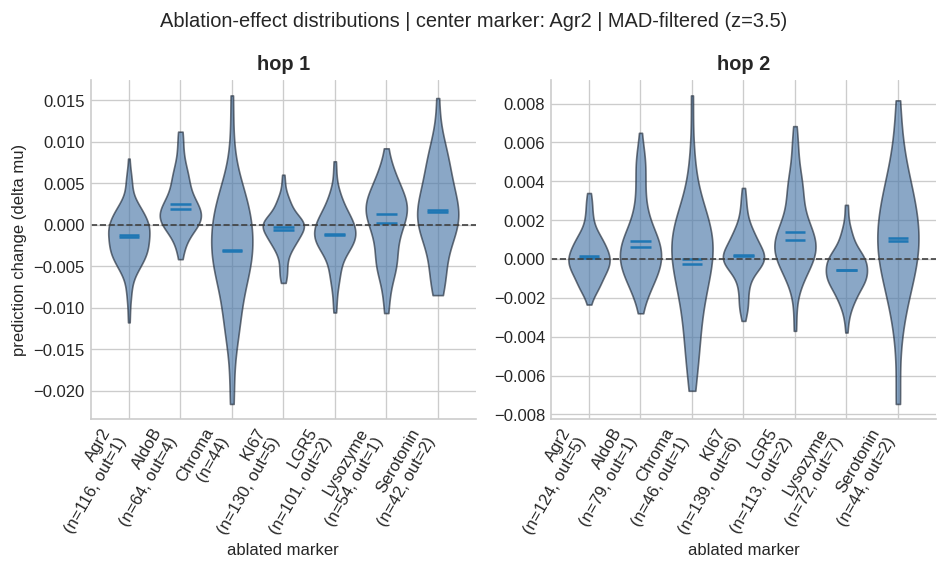

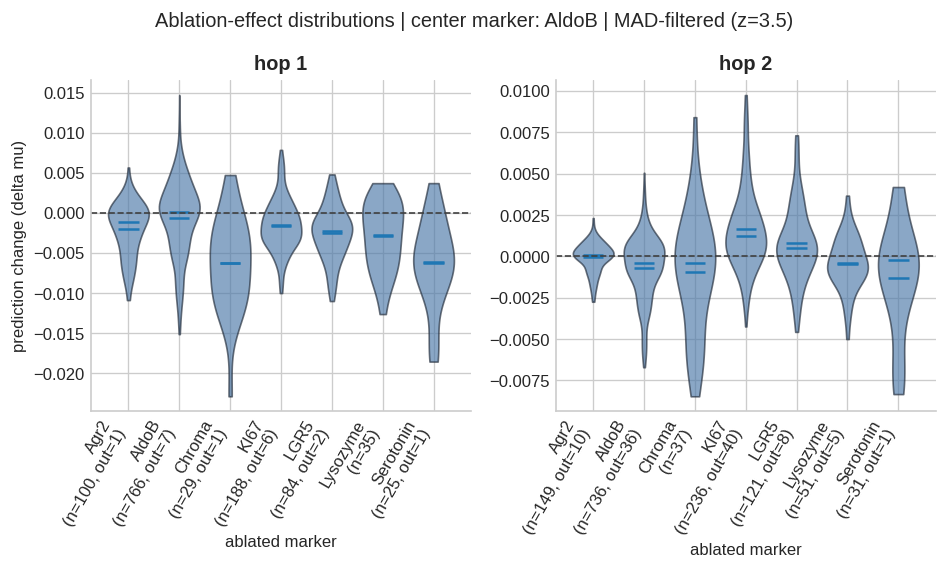

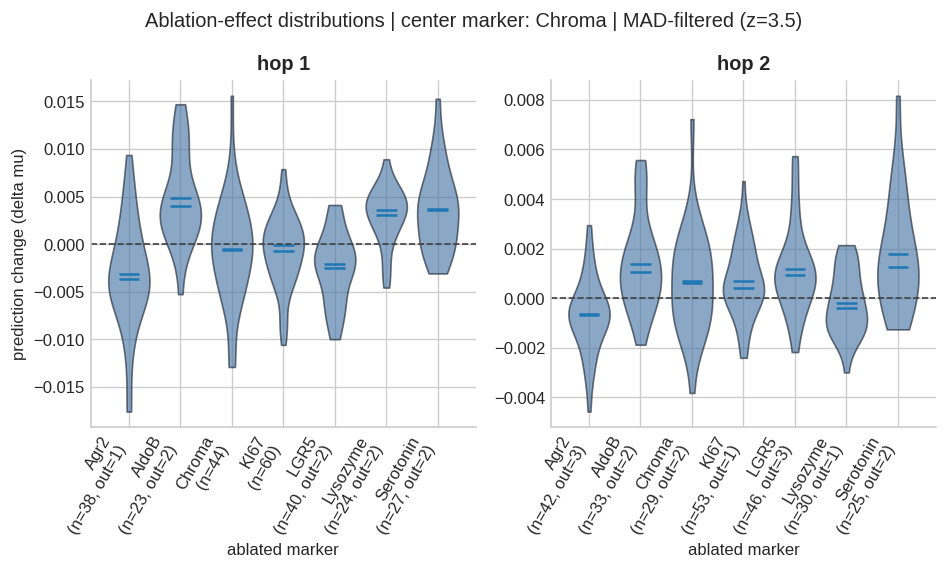

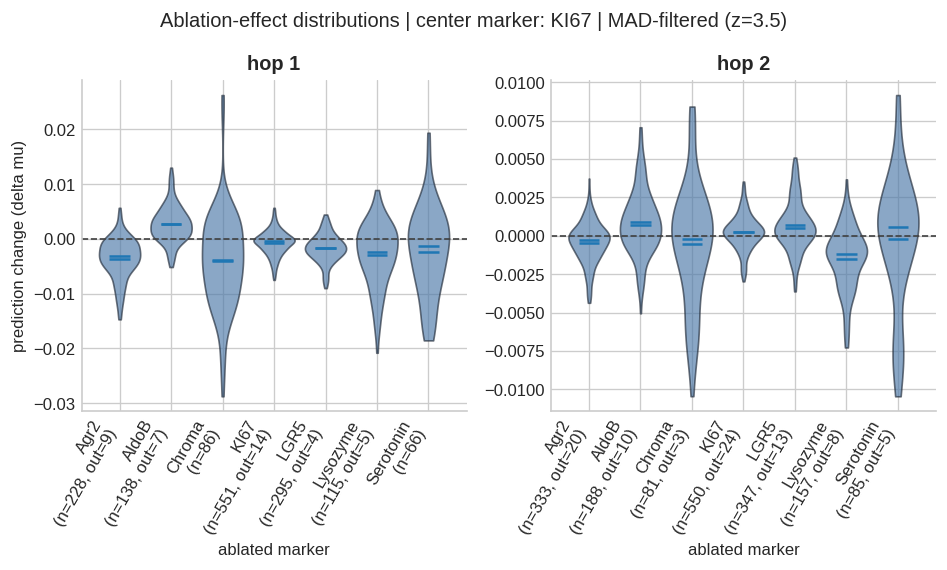

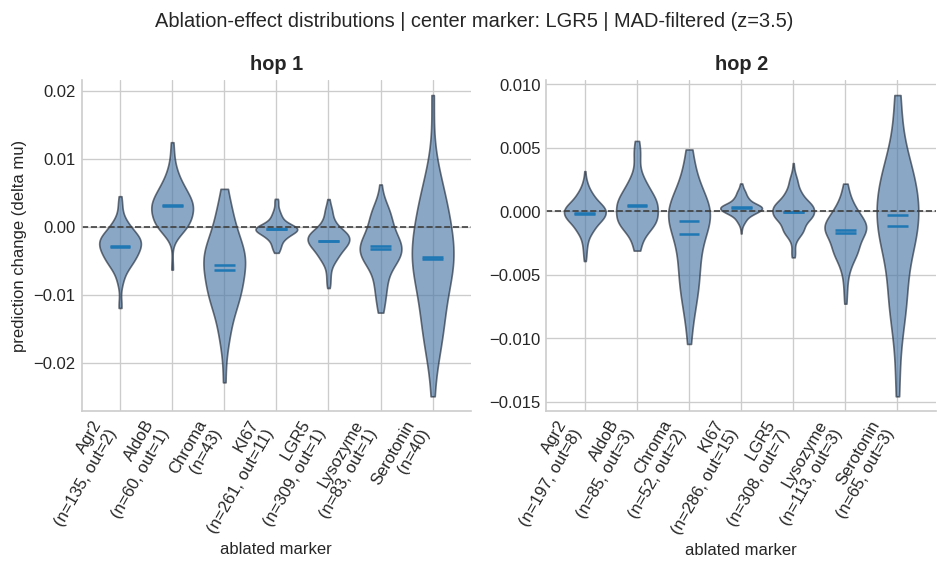

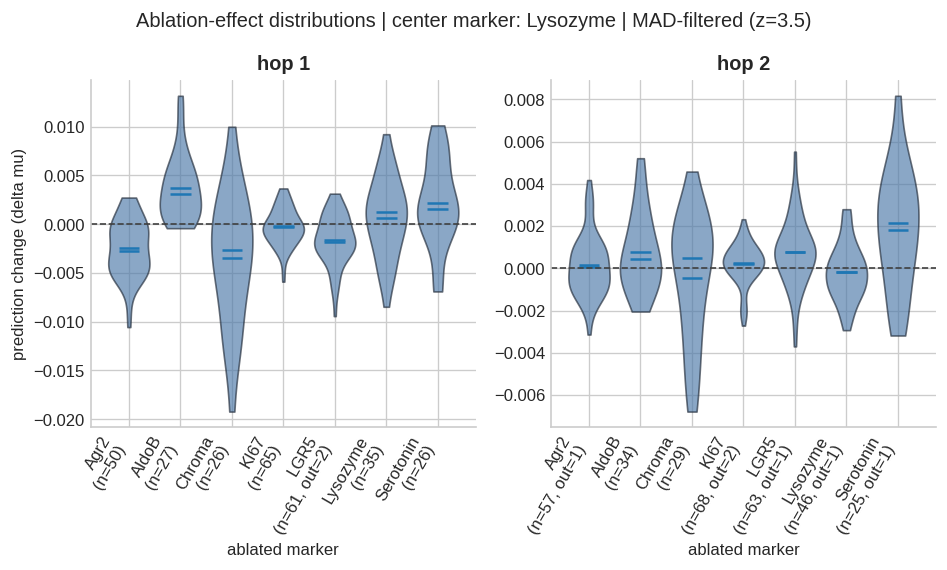

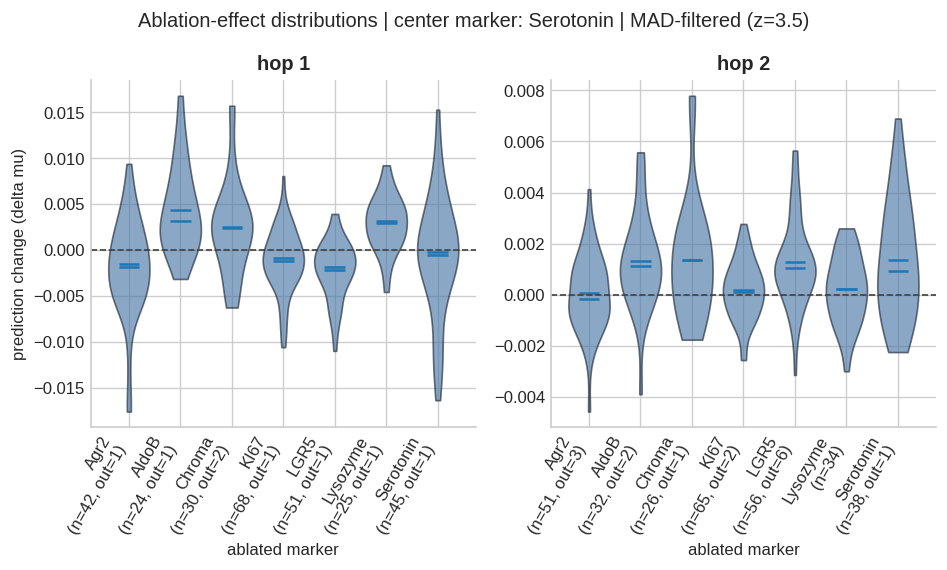

In [11]:
def plot_pair_distributions(pair_df, center_marker, marker_names, hops):
    fig, axes = plt.subplots(
        1, len(hops),
        figsize=(max(4.0 * len(hops), 8.0), 4.8),
        sharey=False,
        squeeze=False,
    )
    axes = axes[0]
    subset = pair_df[pair_df["center_marker"] == center_marker]

    for ax, hop in zip(axes, hops):
        hop_df = subset[subset["hop"] == hop]
        positions = []
        distributions = []
        labels = []
        for marker_idx, marker in enumerate(marker_names):
            marker_df = hop_df[hop_df["source_marker"] == marker_idx]
            values = marker_df.loc[~marker_df["is_outlier"], "delta_mu"].dropna().to_numpy()
            n_removed = int(marker_df["is_outlier"].sum())
            if len(values):
                positions.append(marker_idx)
                distributions.append(values)
                suffix = f", out={n_removed}" if n_removed else ""
                labels.append(f"{marker}\n(n={len(values)}{suffix})")

        if distributions:
            parts = ax.violinplot(
                distributions,
                positions=positions,
                widths=0.8,
                showmeans=True,
                showmedians=True,
                showextrema=False,
            )
            for body in parts["bodies"]:
                body.set_facecolor("#4C78A8")
                body.set_edgecolor("#1F2937")
                body.set_alpha(0.65)
        ax.axhline(0.0, color="0.25", linestyle="--", linewidth=1)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=60, ha="right")
        ax.set_title(f"hop {hop}")
        ax.set_xlabel("ablated marker")

    axes[0].set_ylabel("prediction change (delta mu)")
    filter_label = "unfiltered" if OUTLIER_FILTER_METHOD is None else f"MAD-filtered (z={OUTLIER_MAD_Z:g})"
    fig.suptitle(
        f"Ablation-effect distributions | center marker: {center_marker} | {filter_label}"
    )
    fig.tight_layout()
    return fig, axes


centers_to_plot = marker_names if DISTRIBUTION_CENTER_MARKERS is None else DISTRIBUTION_CENTER_MARKERS
for center_marker in centers_to_plot:
    fig, axes = plot_pair_distributions(
        coverage_pairs, center_marker, marker_names, coverage_result["hops"],
    )
    save_figure(fig, f"coverage_distributions_center_{center_marker}")
    plt.show()


## 5. Population Samples

For each weighting scheme:

- `prevalence` estimates \(P(X\text{ present at }d)\) from the representative draw only.
- `conditional_effect` estimates \(E[\Delta\mu\mid X\text{ present at }d]\) from a separate marker-specific sample.
- `population_effect` is their product.

For every marker and hop, the marker-specific sample starts with eligible centers from the representative draw and is topped up from the full validation pool until `MIN_MARKER_COUNT_PER_HOP` is reached, where possible. These top-ups are used only for that marker's conditional effect and never enter prevalence estimates or another marker's sample.


In [12]:
from src.data.subgraph_sampling import sample_subgraphs_population


def run_population_analysis(weighting):
    population_subgraphs, sample_info = sample_subgraphs_population(
        val_subgraphs,
        max_subgraphs=POPULATION_SAMPLE_SIZE,
        weighting=weighting,
        seed=SUBGRAPH_SEED,
        marker_names=marker_names,
        k_hops=NUM_LAYERS,
        min_marker_count_per_hop=MIN_MARKER_COUNT_PER_HOP,
    )
    print(
        f"{weighting}: population={sample_info['n_population']}, "
        f"groups={len(sample_info['population_group_counts'])}"
    )

    marker_runs = {}
    for marker in marker_names:
        source_by_hop = sample_info["marker_sample_source_indices_by_hop"][marker]
        union_source = []
        seen = set()
        for hop in range(1, NUM_LAYERS + 1):
            for source_idx in source_by_hop[hop]:
                source_idx = int(source_idx)
                if source_idx not in seen:
                    union_source.append(source_idx)
                    seen.add(source_idx)

        source_to_local = {source_idx: i for i, source_idx in enumerate(union_source)}
        local_indices_by_hop = {
            hop: np.asarray(
                [source_to_local[int(source_idx)] for source_idx in source_by_hop[hop]],
                dtype=int,
            )
            for hop in range(1, NUM_LAYERS + 1)
        }
        marker_subgraphs = [val_subgraphs[source_idx] for source_idx in union_source]
        result = compute_perturbation_influence_maps(
            marker_subgraphs,
            model,
            marker_names,
            k_hops=NUM_LAYERS,
            mode="single",
            max_subgraphs=None,
            batch_size=PERTURB_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_ANALYSIS,
            target_transform=target_transform,
            normalize_by="cases",
            return_case_effects=True,
            source_markers=[marker],
        )
        marker_runs[marker] = {
            "subgraphs": marker_subgraphs,
            "result": result,
            "source_indices": np.asarray(union_source, dtype=int),
            "local_indices_by_hop": local_indices_by_hop,
            "weights_by_hop": sample_info["marker_sample_weights_by_hop"][marker],
        }

    sampled_counts = {
        marker: {
            hop: len(sample_info["marker_sample_source_indices_by_hop"][marker][hop])
            for hop in range(1, NUM_LAYERS + 1)
        }
        for marker in marker_names
    }
    print("Marker-specific conditional sample sizes:", sampled_counts)
    return {
        "population_subgraphs": population_subgraphs,
        "sample_info": sample_info,
        "marker_runs": marker_runs,
    }


population_runs = {
    weighting: run_population_analysis(weighting)
    for weighting in ("cell", "organoid")
}


cell: population=2000, groups=161
Marker-specific conditional sample sizes: {'Agr2': {1: 360, 2: 610}, 'AldoB': {1: 1047, 2: 1215}, 'Chroma': {1: 75, 2: 75}, 'KI67': {1: 957, 2: 1232}, 'LGR5': {1: 486, 2: 641}, 'Lysozyme': {1: 111, 2: 206}, 'Serotonin': {1: 75, 2: 75}}
organoid: population=2000, groups=162
Marker-specific conditional sample sizes: {'Agr2': {1: 405, 2: 738}, 'AldoB': {1: 1045, 2: 1224}, 'Chroma': {1: 75, 2: 78}, 'KI67': {1: 1065, 2: 1318}, 'LGR5': {1: 502, 2: 685}, 'Lysozyme': {1: 134, 2: 272}, 'Serotonin': {1: 75, 2: 75}}


In [13]:
from src.graph.neighborhood import compute_hop_rings


def population_marker_prevalence(population_subgraphs, population_weights, marker_idx, hop):
    present = np.zeros(len(population_subgraphs), dtype=bool)
    for i, subgraph in enumerate(population_subgraphs):
        rings = compute_hop_rings(
            subgraph.edge_index,
            int(subgraph.center_idx),
            NUM_LAYERS,
        )
        nodes = rings[hop]
        if len(nodes):
            present[i] = bool((subgraph.x[nodes, marker_idx] > 0.5).any().item())
    return float(np.asarray(population_weights, dtype=float)[present].sum())


def population_effect_table(run, marker_names):
    population_subgraphs = run["population_subgraphs"]
    sample_info = run["sample_info"]
    marker_runs = run["marker_runs"]
    population_weights = np.asarray(sample_info["population_weights"], dtype=float)

    rows = []
    for source_idx, marker in enumerate(marker_names):
        marker_run = marker_runs[marker]
        cases = pd.DataFrame(marker_run["result"]["case_effects"])
        for hop in range(1, NUM_LAYERS + 1):
            sample_positions = marker_run["local_indices_by_hop"][hop]
            sample_weights = np.asarray(marker_run["weights_by_hop"][hop], dtype=float)
            hop_cases = cases[
                (cases["hop"] == hop)
                & (cases["source_marker"] == source_idx)
                & (cases["subgraph_index"].isin(sample_positions))
            ].copy()
            weight_map = dict(zip(sample_positions.tolist(), sample_weights.tolist()))
            hop_cases["sample_weight"] = hop_cases["subgraph_index"].map(weight_map).astype(float)
            hop_cases["is_outlier"] = robust_outlier_mask(
                hop_cases["delta_mu"].to_numpy(float),
                hop_cases["sample_weight"].to_numpy(float),
            )
            kept_cases = hop_cases.loc[~hop_cases["is_outlier"]]
            conditional = weighted_mean(
                kept_cases["delta_mu"].to_numpy(float),
                kept_cases["sample_weight"].to_numpy(float),
            )
            prevalence = population_marker_prevalence(
                population_subgraphs,
                population_weights,
                source_idx,
                hop,
            )
            n_topup = len(
                sample_info["marker_topup_source_indices_by_hop"][marker][hop]
            )
            rows.append({
                "weighting": sample_info["weighting"],
                "hop": hop,
                "source_marker": source_idx,
                "marker": marker,
                "prevalence": prevalence,
                "conditional_effect": conditional,
                "population_effect": prevalence * conditional,
                "conditional_cases": len(kept_cases),
                "outlier_cases": int(hop_cases["is_outlier"].sum()),
                "unfiltered_conditional_cases": len(hop_cases),
                "topup_cases": n_topup,
                "available_cases": sample_info["marker_available_by_hop"][marker][hop],
            })
    return pd.DataFrame(rows)


population_effects = pd.concat(
    [population_effect_table(run, marker_names) for run in population_runs.values()],
    ignore_index=True,
)
population_effects.to_csv(TABLES_DIR / "population_ablation_effects.csv", index=False)
display(population_effects.head(12))


,weighting,hop,source_marker,marker,prevalence,conditional_effect,population_effect,conditional_cases,outlier_cases,unfiltered_conditional_cases,topup_cases,available_cases
0,cell,1,0,Agr2,0.1800,-0.002982,-0.000537,352,8,360,0,15323
1,cell,2,0,Agr2,0.3050,-0.000337,-0.000103,570,40,610,0,25881
2,cell,1,1,AldoB,0.5235,-0.000463,-0.000243,1031,16,1047,0,40505
3,cell,2,1,AldoB,0.6075,-0.000143,-0.000087,1120,95,1215,0,47072
4,cell,1,2,Chroma,0.0150,-0.005492,-0.000082,73,2,75,45,1410
5,cell,2,2,Chroma,0.0365,-0.001473,-0.000054,73,2,75,2,2873
6,cell,1,3,KI67,0.4785,-0.000870,-0.000416,927,30,957,0,39539
7,cell,2,3,KI67,0.6160,0.000493,0.000304,1107,125,1232,0,49104
8,cell,1,4,LGR5,0.2430,-0.001796,-0.000436,472,14,486,0,19600
9,cell,2,4,LGR5,0.3205,0.000779,0.000250,613,28,641,0,26157


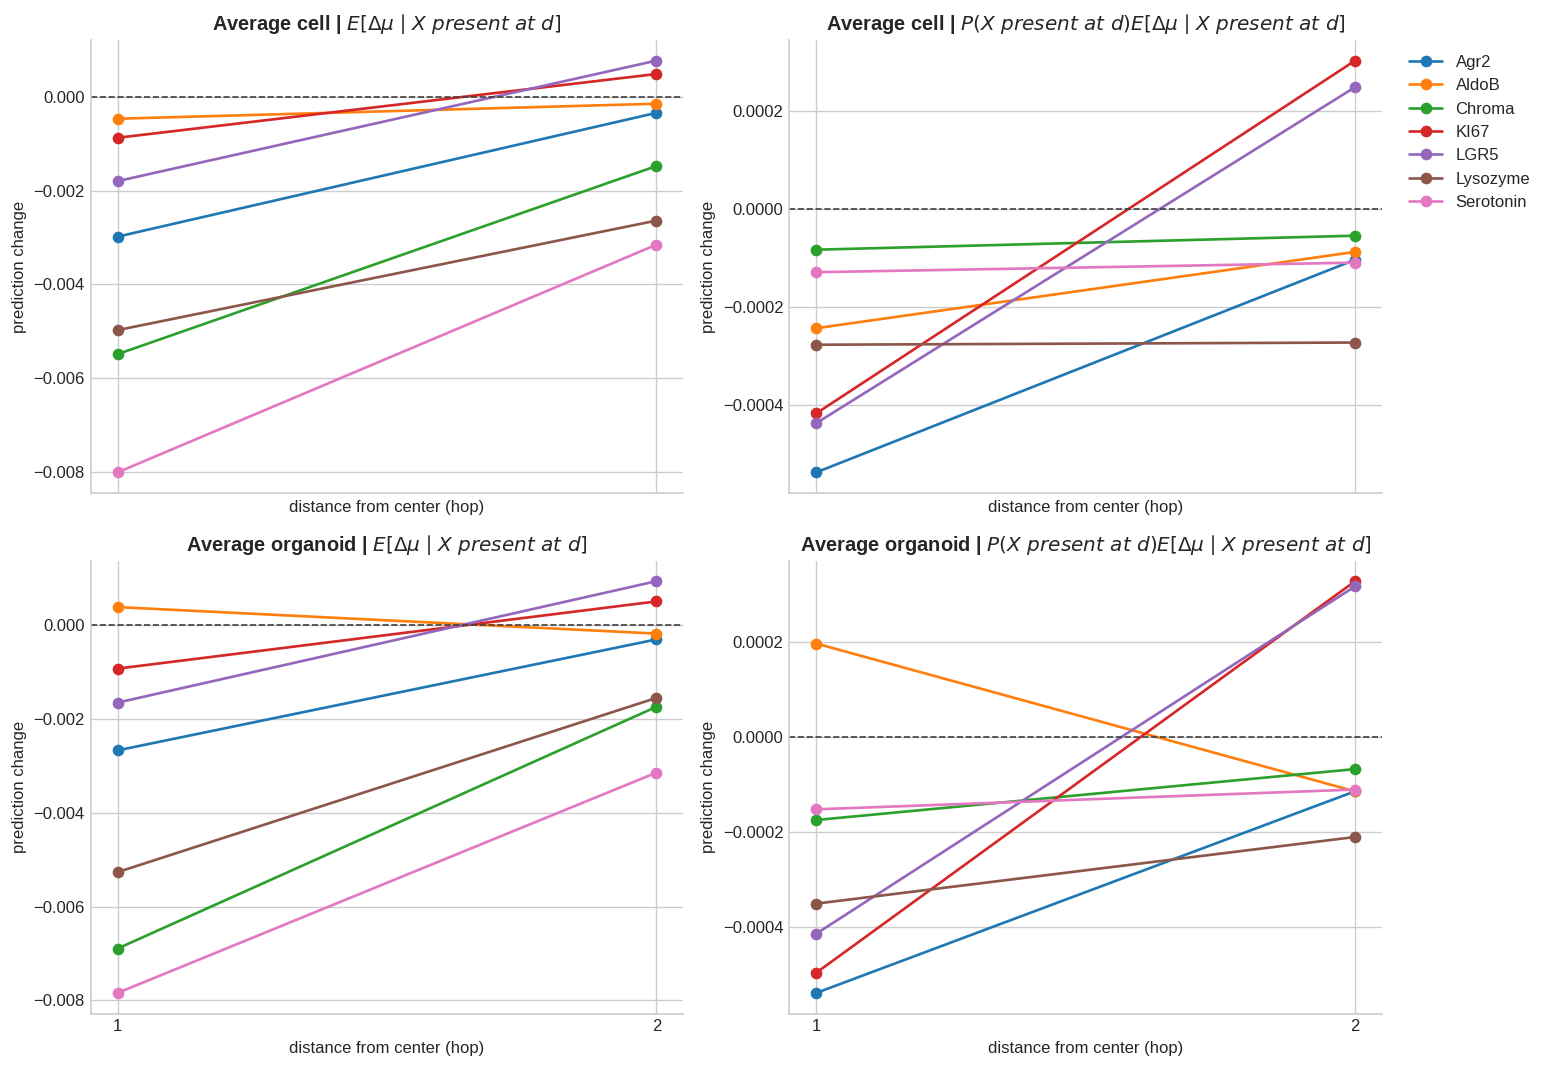

In [14]:
def plot_population_curves(effect_df, marker_names):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    columns = [
        ("conditional_effect", r"$E[\Delta\mu \mid X\ present\ at\ d]$"),
        ("population_effect", r"$P(X\ present\ at\ d) E[\Delta\mu \mid X\ present\ at\ d]$"),
    ]
    for row, weighting in enumerate(("cell", "organoid")):
        subset = effect_df[effect_df["weighting"] == weighting]
        for col, (value_col, title) in enumerate(columns):
            ax = axes[row, col]
            for marker in marker_names:
                marker_df = subset[subset["marker"] == marker].sort_values("hop")
                ax.plot(
                    marker_df["hop"], marker_df[value_col],
                    marker="o", linewidth=1.6, label=marker,
                )
            ax.axhline(0.0, color="0.25", linestyle="--", linewidth=1)
            ax.set_title(f"Average {weighting} | {title}")
            ax.set_xlabel("distance from center (hop)")
            ax.set_ylabel("prediction change")
            ax.set_xticks(sorted(subset["hop"].unique()))
    axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    return fig, axes

fig, axes = plot_population_curves(population_effects, marker_names)
save_figure(fig, "population_conditional_and_prevalence_weighted_effects")
plt.show()


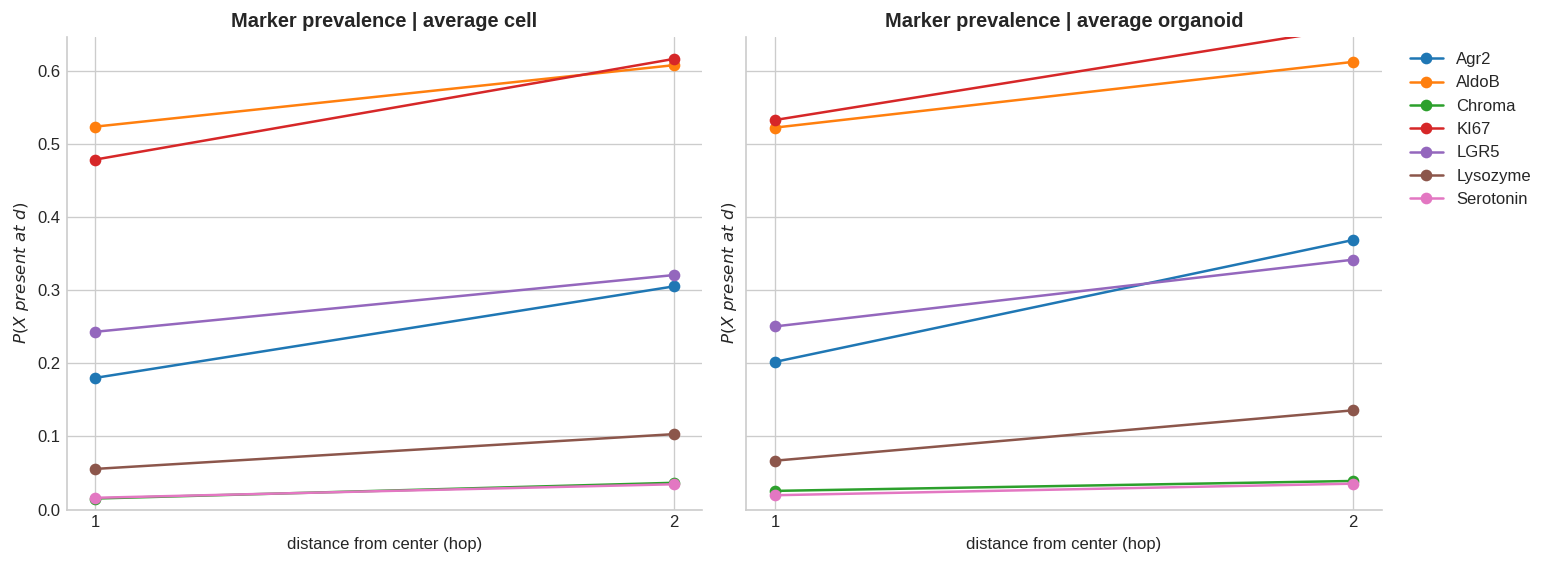

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, weighting in zip(axes, ("cell", "organoid")):
    subset = population_effects[population_effects["weighting"] == weighting]
    for marker in marker_names:
        marker_df = subset[subset["marker"] == marker].sort_values("hop")
        ax.plot(marker_df["hop"], marker_df["prevalence"], marker="o", label=marker)
    ax.set_title(f"Marker prevalence | average {weighting}")
    ax.set_xlabel("distance from center (hop)")
    ax.set_ylabel(r"$P(X\ present\ at\ d)$")
    ax.set_ylim(bottom=0)
    ax.set_xticks(sorted(subset["hop"].unique()))
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_figure(fig, "population_marker_prevalence")
plt.show()


## 6. Sampling Diagnostics


In [16]:
coverage_sampling_summary_df = pd.DataFrame([
    {
        "sampler": sample_name,
        "is_active_sampler": sample_name == HEATMAP_SAMPLER,
        "sample_size": len(run["subgraphs"]),
        "min_center_count": HEATMAP_MIN_CENTER_COUNT,
        "min_pair_count": HEATMAP_MIN_PAIR_COUNT,
        "reuse_penalty": (
            HEATMAP_REUSE_PENALTY if sample_name == "reuse_aware" else np.nan
        ),
        "fill_reuse_penalty": (
            HEATMAP_FILL_REUSE_PENALTY if sample_name == "reuse_aware" else np.nan
        ),
        "max_source_cell_reuse": run["info"].get("max_source_cell_reuse", np.nan),
        "unsatisfied_pair_features": len(run["info"].get("unsatisfied_pair_features", [])),
        "non_overlap_cases_retained": run["info"].get("non_overlap_cases_retained", np.nan),
        "non_overlap_cases_excluded": run["info"].get("non_overlap_cases_excluded", np.nan),
    }
    for sample_name, run in center_sampling_runs.items()
])
coverage_sampling_summary_df.to_csv(
    TABLES_DIR / "coverage_sampling_summary.csv",
    index=False,
)
display(coverage_sampling_summary_df)

diagnostics = []
for weighting, run in population_runs.items():
    sample_info = run["sample_info"]
    for marker in marker_names:
        for hop in range(1, NUM_LAYERS + 1):
            diagnostics.append({
                "weighting": weighting,
                "marker": marker,
                "hop": hop,
                "n_population": sample_info["n_population"],
                "available": sample_info["marker_available_by_hop"][marker][hop],
                "sampled": len(
                    sample_info["marker_sample_source_indices_by_hop"][marker][hop]
                ),
                "topped_up": len(
                    sample_info["marker_topup_source_indices_by_hop"][marker][hop]
                ),
            })
diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df.to_csv(TABLES_DIR / "sampling_diagnostics.csv", index=False)
display(diagnostics_df)

settings = {
    "created_at": RUN_TIMESTAMP,
    "save_dir": SAVE_DIR,
    "dataset": {
        "name": DATASET_NAME,
        "target_indices": TARGET_INDICES,
        "target_index_for_analysis": TARGET_INDEX_FOR_ANALYSIS,
    },
    "filtering": {
        "timepoint_filter_mode": TIMEPOINT_FILTER_MODE,
        "day3p5_timepoint": DAY3P5_TIMEPOINT,
        "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
        "apply_quality_filters": APPLY_QUALITY_FILTERS,
        "fill_missing_complexity": FILL_MISSING_COMPLEXITY,
        "apply_complexity_filter": APPLY_COMPLEXITY_FILTER,
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    },
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
    },
    "model": {
        "num_layers": NUM_LAYERS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
        "use_global_features": USE_GLOBAL_FEATURES,
        "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
    },
    "sampling": {
        "perturbation_mode": PERTURBATION_MODE,
        "subgraph_seed": SUBGRAPH_SEED,
        "perturb_batch_size": PERTURB_BATCH_SIZE,
        "heatmap_sample_size": HEATMAP_SAMPLE_SIZE,
        "heatmap_min_center_count": HEATMAP_MIN_CENTER_COUNT,
        "heatmap_min_pair_count": HEATMAP_MIN_PAIR_COUNT,
        "heatmap_sampler": HEATMAP_SAMPLER,
        "heatmap_comparison_samplers": HEATMAP_COMPARISON_SAMPLERS,
        "non_overlap_group_columns": ["hop", "center_marker", "source_marker"],
        "heatmap_reuse_penalty": HEATMAP_REUSE_PENALTY,
        "heatmap_fill_reuse_penalty": HEATMAP_FILL_REUSE_PENALTY,
        "heatmap_display_min_cases": HEATMAP_DISPLAY_MIN_CASES,
        "population_sample_size": POPULATION_SAMPLE_SIZE,
        "min_marker_count_per_hop": MIN_MARKER_COUNT_PER_HOP,
    },
    "outlier_filtering": {
        "method": OUTLIER_FILTER_METHOD,
        "mad_z": OUTLIER_MAD_Z,
        "min_group_size": OUTLIER_MIN_GROUP_SIZE,
        "tail": OUTLIER_TAIL,
    },
}
with open(SAVE_DIR / "settings.json", "w") as handle:
    json.dump(jsonable(settings), handle, indent=2)

print("Saved analysis to", SAVE_DIR)


,sampler,is_active_sampler,sample_size,min_center_count,min_pair_count,reuse_penalty,fill_reuse_penalty,max_source_cell_reuse,unsatisfied_pair_features,non_overlap_cases_retained,non_overlap_cases_excluded
0,coverage,True,2000,50,25,NaN,NaN,NaN,0,NaN,NaN
1,non_overlapping,False,2000,50,25,NaN,NaN,NaN,0,9934.0,2627.0


,weighting,marker,hop,n_population,available,sampled,topped_up
0,cell,Agr2,1,2000,15323,360,0
1,cell,Agr2,2,2000,25881,610,0
2,cell,AldoB,1,2000,40505,1047,0
3,cell,AldoB,2,2000,47072,1215,0
4,cell,Chroma,1,2000,1410,75,45
5,cell,Chroma,2,2000,2873,75,2
6,cell,KI67,1,2000,39539,957,0
7,cell,KI67,2,2000,49104,1232,0
8,cell,LGR5,1,2000,19600,486,0
9,cell,LGR5,2,2000,26157,641,0


Saved analysis to /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/ablation_sampling/rest_depth2_after_cleanup_sampling_comparison_20260709_150444


## 7. Physical Cell Reuse Across Sampled Subgraphs

A physical cell is identified by `(graph_idx, original node index)`. For each sampling design, its reuse count is the number of distinct sampled ego-subgraphs whose `orig_nodes` contains that cell. Marker-positive cells that never appear are retained in the diagnostic table and reported as `zero` in each panel; the histogram itself shows represented cells so the reuse tail remains visible.


In [17]:
from collections import Counter


def subgraph_membership_counts(sampled_subgraphs):
    counts = Counter()
    for subgraph in sampled_subgraphs:
        if not hasattr(subgraph, "graph_idx") or not hasattr(subgraph, "orig_nodes"):
            raise ValueError("Expected sampled subgraphs with graph_idx and orig_nodes.")
        graph_idx = int(subgraph.graph_idx)
        original_nodes = subgraph.orig_nodes.detach().cpu().numpy().astype(
            int,
            copy=False,
        ).reshape(-1)
        for node_idx in original_nodes:
            counts[(graph_idx, int(node_idx))] += 1
    return counts


def marker_cell_reuse_table(graphs, sampled_subgraphs, marker_names, *, sample_name):
    membership = subgraph_membership_counts(sampled_subgraphs)
    rows = []
    for graph_idx, graph in enumerate(graphs):
        marker_positive = np.asarray(graph.x.detach().cpu()) > 0.5
        organoid = getattr(graph, "organoid_str", f"graph_{graph_idx}")
        for marker_idx, marker in enumerate(marker_names):
            for node_idx in np.flatnonzero(marker_positive[:, marker_idx]):
                rows.append({
                    "sample": sample_name,
                    "graph_idx": graph_idx,
                    "organoid_str": organoid,
                    "node_idx": int(node_idx),
                    "marker": marker,
                    "reuse_count": int(membership.get((graph_idx, int(node_idx)), 0)),
                })
    return pd.DataFrame(rows)


def marker_specific_reuse_table(graphs, marker_runs, marker_names, *, sample_name):
    tables = []
    for marker in marker_names:
        table = marker_cell_reuse_table(
            graphs,
            marker_runs[marker]["subgraphs"],
            marker_names,
            sample_name=sample_name,
        )
        tables.append(table[table["marker"] == marker])
    return pd.concat(tables, ignore_index=True)


def plot_marker_reuse_histograms(reuse_df, marker_names, title, filename):
    n_markers = len(marker_names)
    n_cols = min(3, n_markers)
    n_rows = int(np.ceil(n_markers / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.4 * n_cols, 3.5 * n_rows),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, marker in zip(axes, marker_names):
        marker_counts = reuse_df.loc[
            reuse_df["marker"] == marker,
            "reuse_count",
        ].to_numpy(int)
        represented = marker_counts[marker_counts > 0]
        n_zero = int((marker_counts == 0).sum())

        if len(represented):
            max_count = int(represented.max())
            bins = np.arange(0.5, max_count + 1.5, 1.0)
            ax.hist(
                represented,
                bins=bins,
                color="#4C78A8",
                edgecolor="white",
                linewidth=0.5,
            )
            median = float(np.median(represented))
            p95 = float(np.quantile(represented, 0.95))
            ax.axvline(p95, color="#E45756", linestyle="--", linewidth=1.5)
            stats = (
                f"cells={len(marker_counts):,} | represented={len(represented):,} | zero={n_zero:,}\n"
                f"median={median:.1f} | p95={p95:.1f} | max={max_count}"
            )
        else:
            stats = f"cells={len(marker_counts):,} | represented=0 | zero={n_zero:,}"
            ax.text(0.5, 0.5, "No represented cells", transform=ax.transAxes, ha="center")

        ax.set_title(marker)
        ax.set_xlabel("sampled subgraphs containing cell")
        ax.set_ylabel("marker-positive cells")
        ax.text(
            0.02,
            0.98,
            stats,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=8.5,
            bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "0.8"},
        )

    for ax in axes[n_markers:]:
        ax.set_visible(False)
    fig.suptitle(title)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()
    return fig, axes


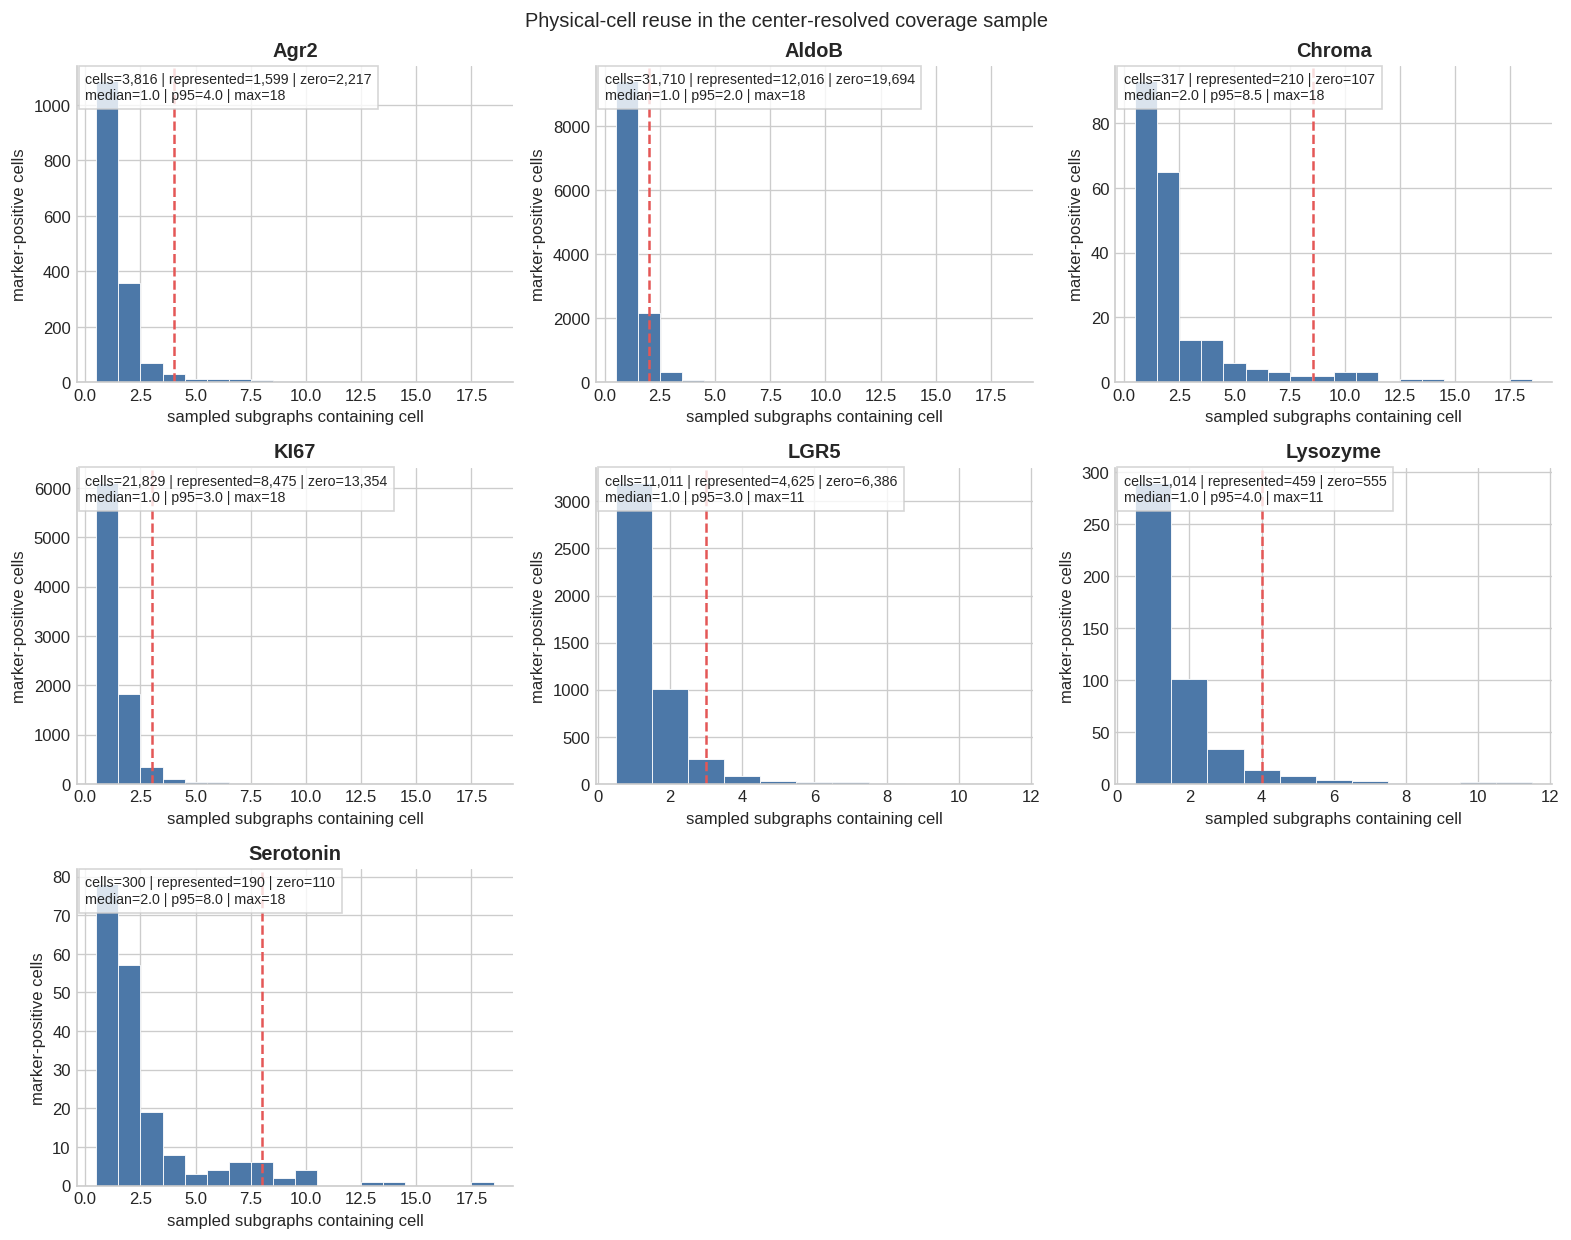

(<Figure size 1584x1260 with 9 Axes>,
 array([<Axes: title={'center': 'Agr2'}, xlabel='sampled subgraphs containing cell', ylabel='marker-positive cells'>,
        <Axes: title={'center': 'AldoB'}, xlabel='sampled subgraphs containing cell', ylabel='marker-positive cells'>,
        <Axes: title={'center': 'Chroma'}, xlabel='sampled subgraphs containing cell', ylabel='marker-positive cells'>,
        <Axes: title={'center': 'KI67'}, xlabel='sampled subgraphs containing cell', ylabel='marker-positive cells'>,
        <Axes: title={'center': 'LGR5'}, xlabel='sampled subgraphs containing cell', ylabel='marker-positive cells'>,
        <Axes: title={'center': 'Lysozyme'}, xlabel='sampled subgraphs containing cell', ylabel='marker-positive cells'>,
        <Axes: title={'center': 'Serotonin'}, xlabel='sampled subgraphs containing cell', ylabel='marker-positive cells'>,
        <Axes: >, <Axes: >], dtype=object))

In [18]:
coverage_reuse_df = marker_cell_reuse_table(
    g_val,
    coverage_subgraphs,
    marker_names,
    sample_name="coverage",
)
coverage_reuse_df.to_csv(TABLES_DIR / "coverage_physical_cell_reuse.csv", index=False)
plot_marker_reuse_histograms(
    coverage_reuse_df,
    marker_names,
    "Physical-cell reuse in the center-resolved coverage sample",
    "coverage_physical_cell_reuse_histograms",
)


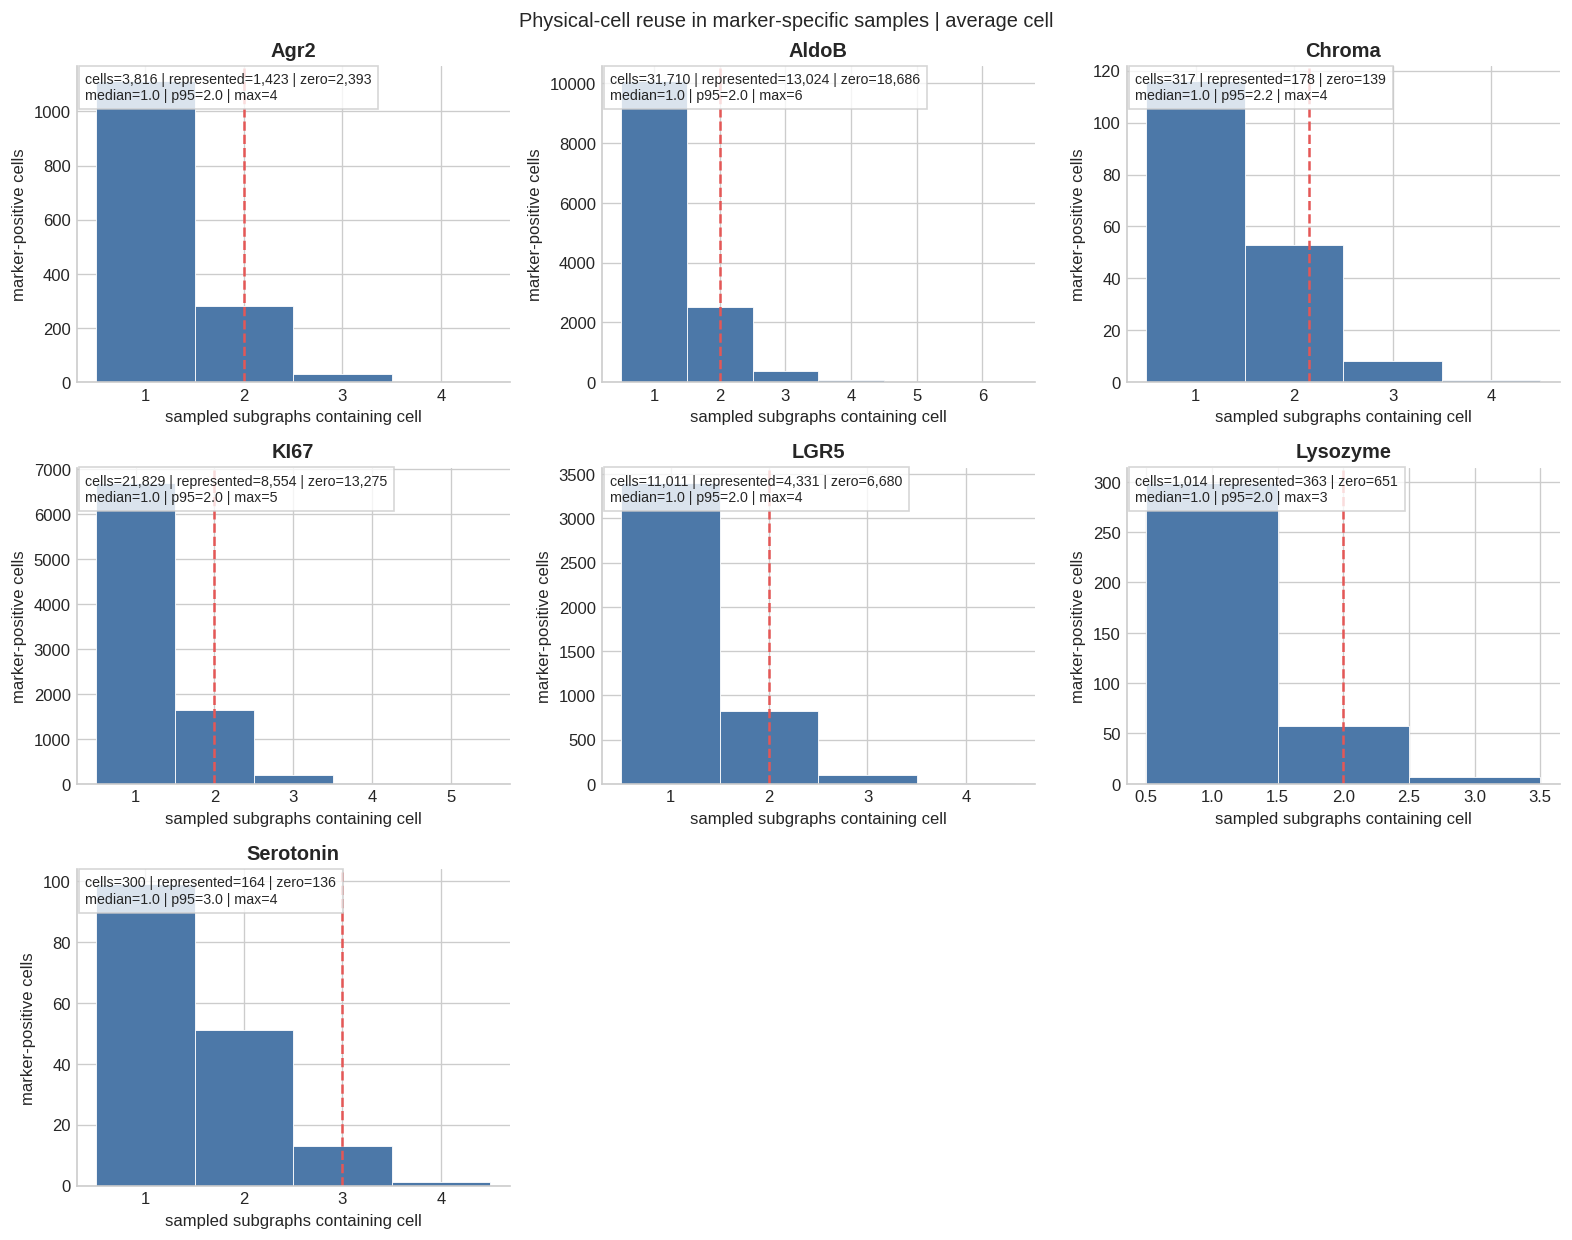

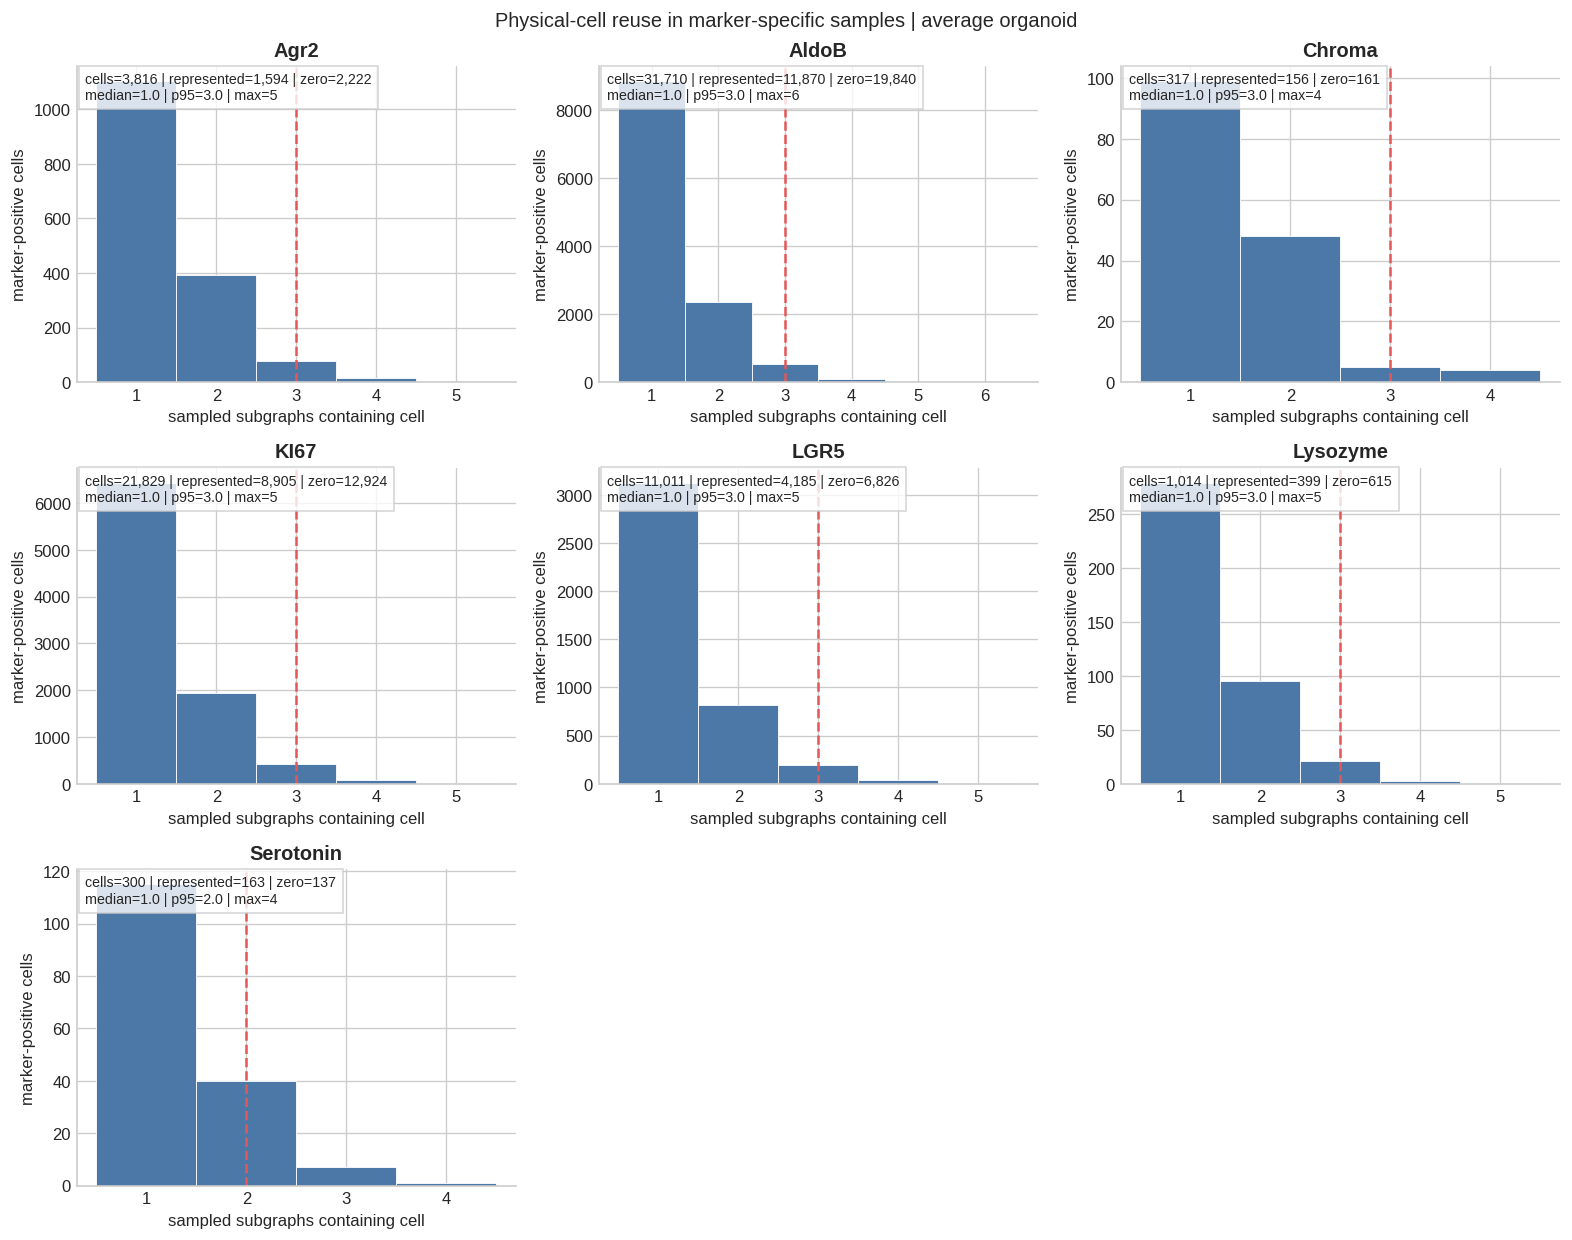

In [19]:
population_reuse_tables = []
for weighting, run in population_runs.items():
    reuse_df = marker_specific_reuse_table(
        g_val,
        run["marker_runs"],
        marker_names,
        sample_name=f"population_{weighting}_marker_specific",
    )
    population_reuse_tables.append(reuse_df)
    reuse_df.to_csv(
        TABLES_DIR / f"population_{weighting}_marker_specific_physical_cell_reuse.csv",
        index=False,
    )
    plot_marker_reuse_histograms(
        reuse_df,
        marker_names,
        f"Physical-cell reuse in marker-specific samples | average {weighting}",
        f"population_{weighting}_marker_specific_physical_cell_reuse_histograms",
    )

population_reuse_df = pd.concat(population_reuse_tables, ignore_index=True)


## 8. Hop-Resolved Physical Cell Reuse

These histograms resolve reuse by exact graph distance from the sampled center. Rows are marker types and columns are hop distances. For marker-specific population samples, each column uses only the subgraphs assigned to that marker at that particular hop, including its hop-specific top-ups.


In [20]:
def hop_membership_counts(sampled_subgraphs, hops, *, subgraph_indices_by_hop=None):
    counts_by_hop = {int(hop): Counter() for hop in hops}
    for hop in hops:
        hop = int(hop)
        if subgraph_indices_by_hop is None:
            selected_indices = range(len(sampled_subgraphs))
        else:
            selected_indices = subgraph_indices_by_hop[hop]

        for subgraph_idx in selected_indices:
            subgraph = sampled_subgraphs[int(subgraph_idx)]
            if not hasattr(subgraph, "graph_idx") or not hasattr(subgraph, "orig_nodes"):
                raise ValueError("Expected sampled subgraphs with graph_idx and orig_nodes.")
            rings = compute_hop_rings(
                subgraph.edge_index,
                int(subgraph.center_idx),
                max(hops),
            )
            local_nodes = np.asarray(rings[hop], dtype=int).reshape(-1)
            if len(local_nodes) == 0:
                continue
            original_nodes = subgraph.orig_nodes.detach().cpu().numpy().astype(
                int,
                copy=False,
            )
            graph_idx = int(subgraph.graph_idx)
            for node_idx in original_nodes[local_nodes]:
                counts_by_hop[hop][(graph_idx, int(node_idx))] += 1
    return counts_by_hop


def marker_hop_reuse_table(
    graphs,
    sampled_subgraphs,
    marker_names,
    hops,
    *,
    sample_name,
    subgraph_indices_by_hop=None,
    markers_to_include=None,
):
    counts_by_hop = hop_membership_counts(
        sampled_subgraphs,
        hops,
        subgraph_indices_by_hop=subgraph_indices_by_hop,
    )
    marker_indices = {
        marker: marker_index(marker)
        for marker in (marker_names if markers_to_include is None else markers_to_include)
    }
    rows = []
    for graph_idx, graph in enumerate(graphs):
        marker_positive = graph.x.detach().cpu().numpy() > 0.5
        organoid = getattr(graph, "organoid_str", f"graph_{graph_idx}")
        for marker, marker_idx in marker_indices.items():
            positive_nodes = np.flatnonzero(marker_positive[:, marker_idx])
            for hop in hops:
                membership = counts_by_hop[int(hop)]
                for node_idx in positive_nodes:
                    rows.append({
                        "sample": sample_name,
                        "graph_idx": graph_idx,
                        "organoid_str": organoid,
                        "node_idx": int(node_idx),
                        "marker": marker,
                        "hop": int(hop),
                        "reuse_count": int(
                            membership.get((graph_idx, int(node_idx)), 0)
                        ),
                    })
    return pd.DataFrame(rows)


def marker_specific_hop_reuse_table(graphs, marker_runs, marker_names, hops, *, sample_name):
    tables = []
    for marker in marker_names:
        marker_run = marker_runs[marker]
        table = marker_hop_reuse_table(
            graphs,
            marker_run["subgraphs"],
            marker_names,
            hops,
            sample_name=sample_name,
            subgraph_indices_by_hop=marker_run["local_indices_by_hop"],
            markers_to_include=[marker],
        )
        tables.append(table)
    return pd.concat(tables, ignore_index=True)


In [21]:
def plot_marker_hop_reuse_grid(reuse_df, marker_names, hops, title, filename):
    fig, axes = plt.subplots(
        len(marker_names),
        len(hops),
        figsize=(3.7 * len(hops), 2.8 * len(marker_names)),
        squeeze=False,
    )

    for row, marker in enumerate(marker_names):
        for col, hop in enumerate(hops):
            ax = axes[row, col]
            counts = reuse_df.loc[
                (reuse_df["marker"] == marker) & (reuse_df["hop"] == hop),
                "reuse_count",
            ].to_numpy(int)
            represented = counts[counts > 0]
            n_zero = int((counts == 0).sum())

            if len(represented):
                max_count = int(represented.max())
                bins = np.arange(0.5, max_count + 1.5, 1.0)
                ax.hist(
                    represented,
                    bins=bins,
                    color="#4C78A8",
                    edgecolor="white",
                    linewidth=0.45,
                )
                median = float(np.median(represented))
                p95 = float(np.quantile(represented, 0.95))
                ax.axvline(p95, color="#E45756", linestyle="--", linewidth=1.3)
                stats = (
                    f"repr={len(represented):,} | zero={n_zero:,}\n"
                    f"med={median:.1f} | p95={p95:.1f} | max={max_count}"
                )
            else:
                stats = f"repr=0 | zero={n_zero:,}"
                ax.text(
                    0.5,
                    0.5,
                    "No represented cells",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                    fontsize=8,
                )

            if row == 0:
                ax.set_title(f"hop {hop}")
            if col == 0:
                ax.set_ylabel(f"{marker}\nmarker-positive cells")
            if row == len(marker_names) - 1:
                ax.set_xlabel("subgraphs containing cell at this hop")
            ax.text(
                0.02,
                0.98,
                stats,
                transform=ax.transAxes,
                va="top",
                ha="left",
                fontsize=7.5,
                bbox={"facecolor": "white", "alpha": 0.82, "edgecolor": "0.82"},
            )

    fig.suptitle(title)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()
    return fig, axes


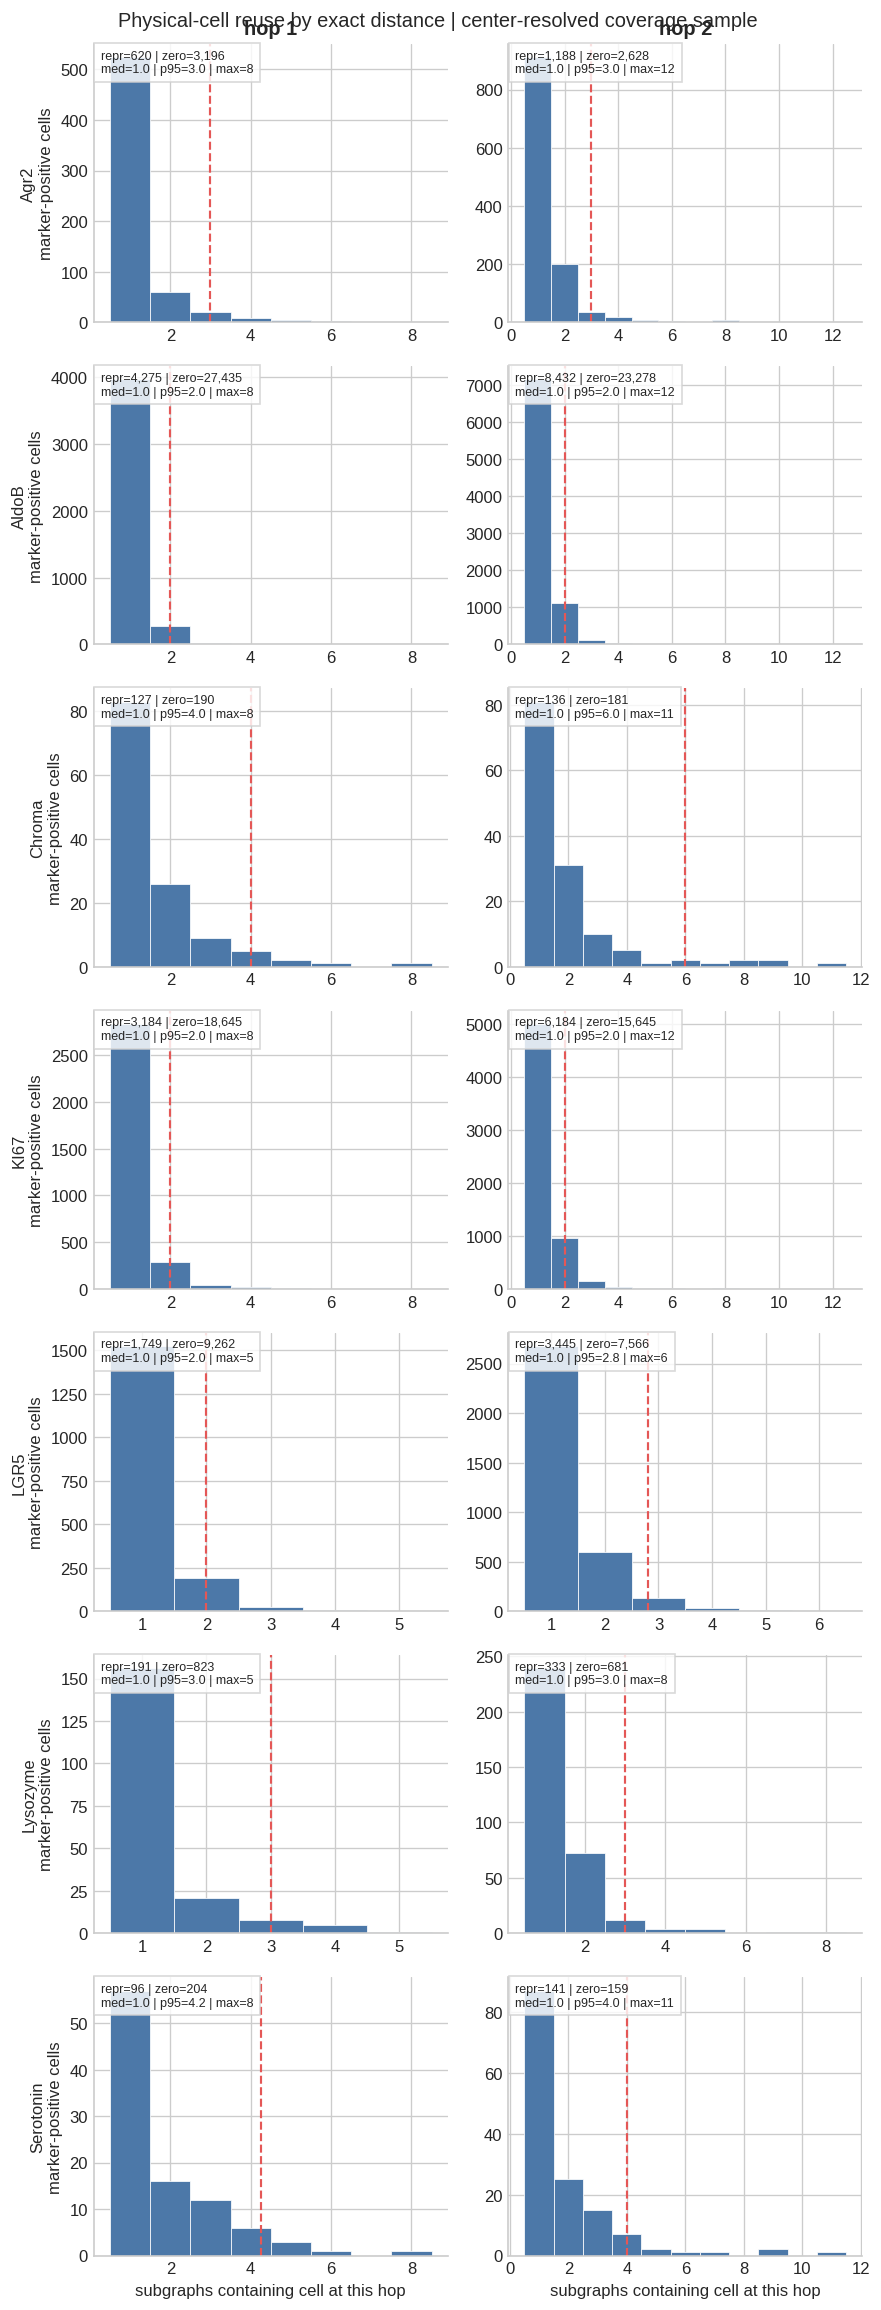

(<Figure size 888x2352 with 14 Axes>,
 array([[<Axes: title={'center': 'hop 1'}, ylabel='Agr2\nmarker-positive cells'>,
         <Axes: title={'center': 'hop 2'}>],
        [<Axes: ylabel='AldoB\nmarker-positive cells'>, <Axes: >],
        [<Axes: ylabel='Chroma\nmarker-positive cells'>, <Axes: >],
        [<Axes: ylabel='KI67\nmarker-positive cells'>, <Axes: >],
        [<Axes: ylabel='LGR5\nmarker-positive cells'>, <Axes: >],
        [<Axes: ylabel='Lysozyme\nmarker-positive cells'>, <Axes: >],
        [<Axes: xlabel='subgraphs containing cell at this hop', ylabel='Serotonin\nmarker-positive cells'>,
         <Axes: xlabel='subgraphs containing cell at this hop'>]],
       dtype=object))

In [22]:
hops = list(range(1, NUM_LAYERS + 1))
coverage_hop_reuse_df = marker_hop_reuse_table(
    g_val,
    coverage_subgraphs,
    marker_names,
    hops,
    sample_name="coverage",
)
coverage_hop_reuse_df.to_csv(
    TABLES_DIR / "coverage_physical_cell_reuse_by_hop.csv",
    index=False,
)
plot_marker_hop_reuse_grid(
    coverage_hop_reuse_df,
    marker_names,
    hops,
    "Physical-cell reuse by exact distance | center-resolved coverage sample",
    "coverage_physical_cell_reuse_by_hop",
)


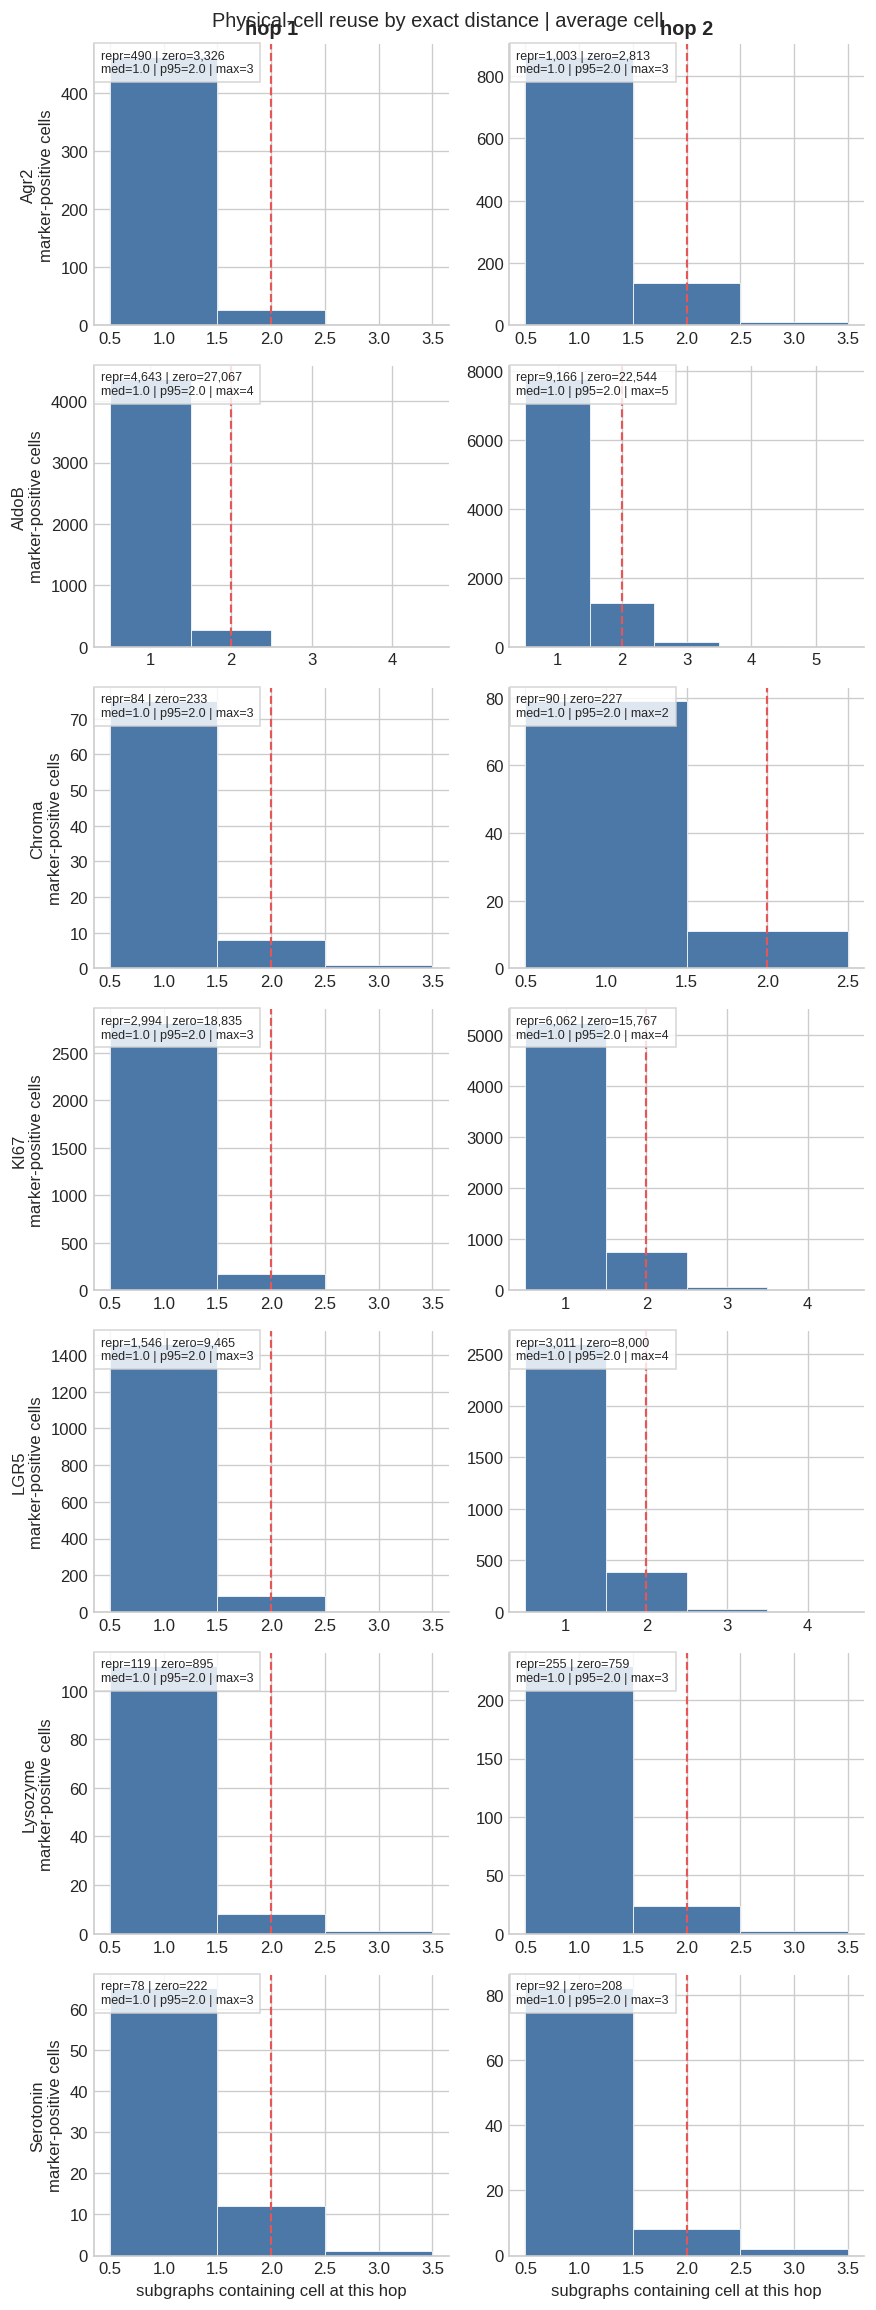

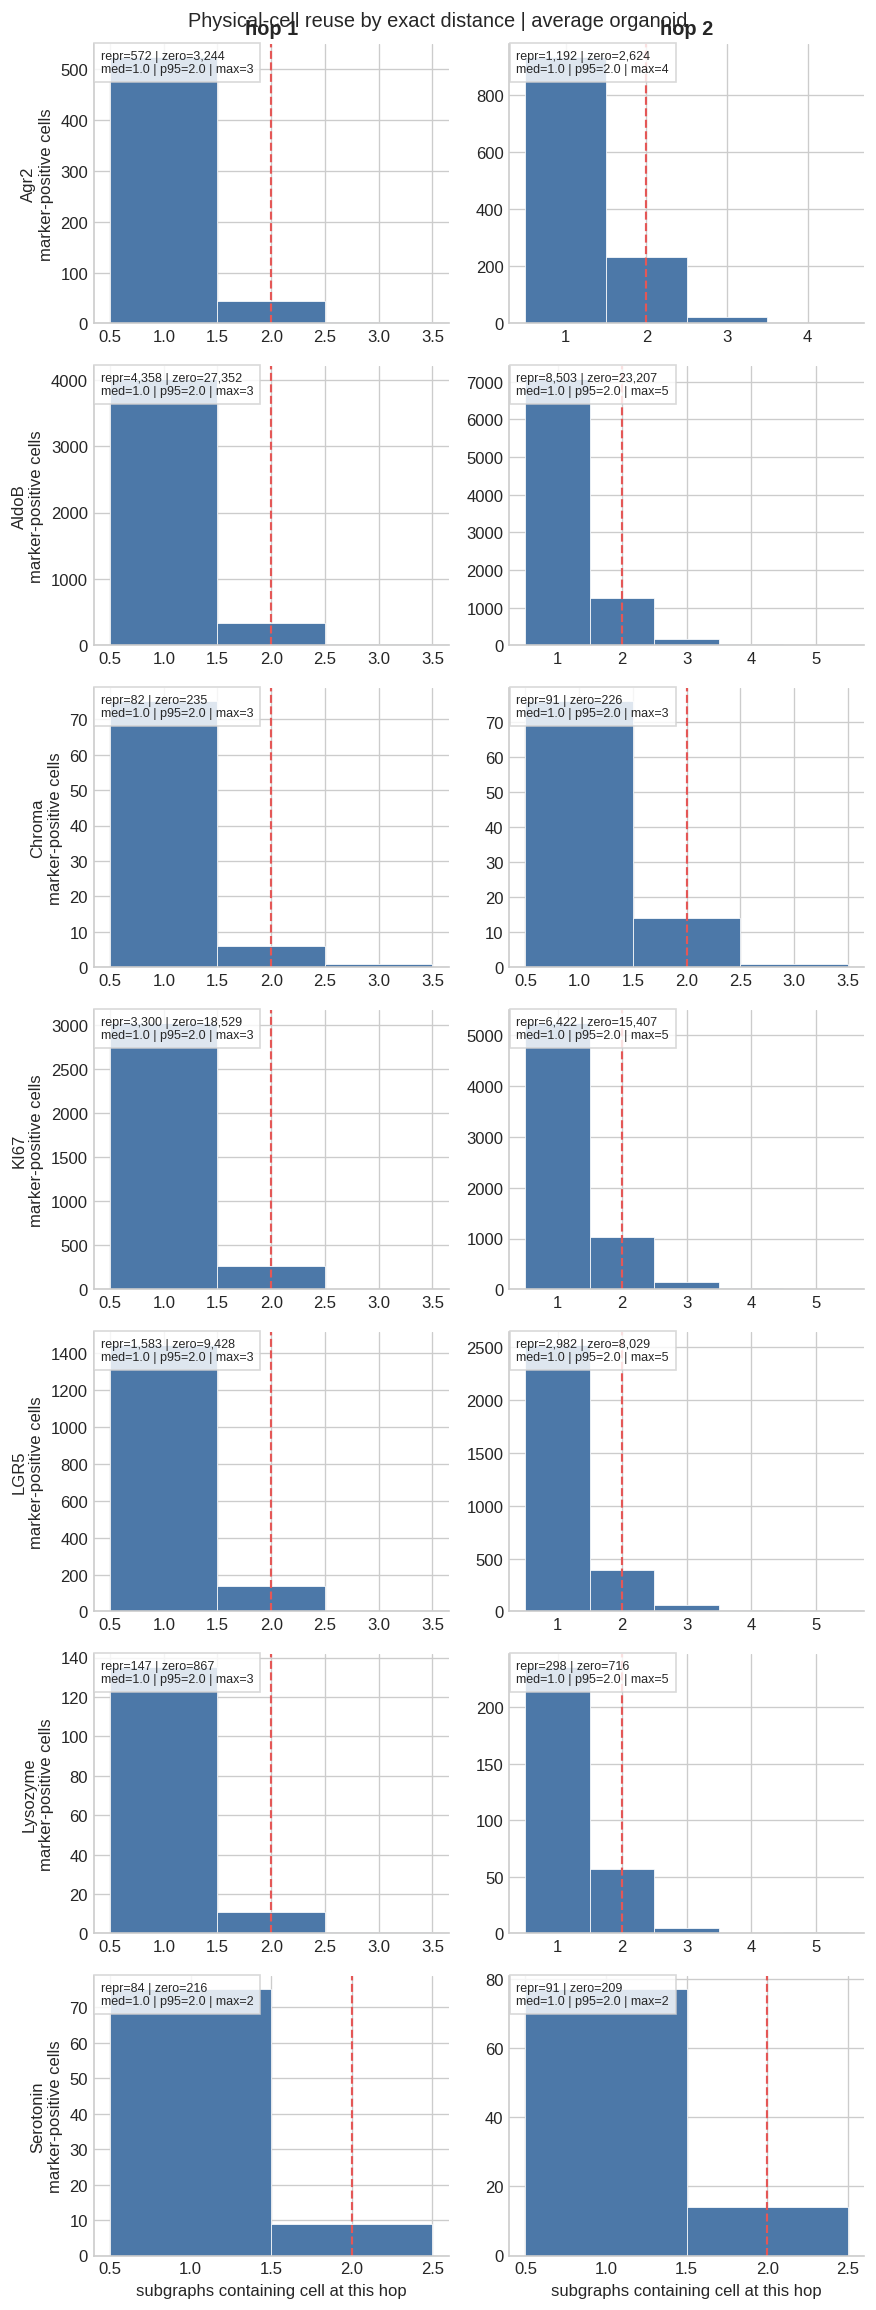

In [23]:
population_hop_reuse_tables = []
for weighting, run in population_runs.items():
    reuse_df = marker_specific_hop_reuse_table(
        g_val,
        run["marker_runs"],
        marker_names,
        hops,
        sample_name=f"population_{weighting}_marker_specific",
    )
    population_hop_reuse_tables.append(reuse_df)
    reuse_df.to_csv(
        TABLES_DIR / f"population_{weighting}_marker_specific_physical_cell_reuse_by_hop.csv",
        index=False,
    )
    plot_marker_hop_reuse_grid(
        reuse_df,
        marker_names,
        hops,
        f"Physical-cell reuse by exact distance | average {weighting}",
        f"population_{weighting}_marker_specific_physical_cell_reuse_by_hop",
    )

population_hop_reuse_df = pd.concat(population_hop_reuse_tables, ignore_index=True)
